[COLAB](https://colab.research.google.com/drive/1sBV8r9x4o0b1lFd4G8vVK_1eendGjIIO?usp=sharing)

#Problem Statement
---

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

You are working as a data scientist with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

#EDA and Preprocessing

In [2]:
!gdown 1KfJBgMjr-1eZvM0jinGIA9BXr8WLn1kF -O scaler.csv

Downloading...
From: https://drive.google.com/uc?id=1KfJBgMjr-1eZvM0jinGIA9BXr8WLn1kF
To: /content/scaler.csv
100% 24.7M/24.7M [00:00<00:00, 59.9MB/s]


In [3]:
df = pd.read_csv('scaler.csv')
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [4]:
df.shape

(205843, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153279 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [6]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [7]:
df.duplicated().sum()

np.int64(34)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.reset_index(drop=True, inplace=True)
df.shape

(205809, 6)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205809 entries, 0 to 205808
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   company_hash      205765 non-null  object 
 1   email_hash        205809 non-null  object 
 2   orgyear           205723 non-null  float64
 3   ctc               205809 non-null  int64  
 4   job_position      153261 non-null  object 
 5   ctc_updated_year  205809 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.4+ MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
orgyear,205723.0,2.014882e+03,6.357635e+01,0.0,2013.0,2016.0,2018.0,2.016500e+04
ctc,205809.0,2.271862e+06,1.180187e+07,2.0,530000.0,950000.0,1700000.0,1.000150e+09
ctc_updated_year,205809.0,2.019628e+03,1.325187e+00,2015.0,2019.0,2020.0,2021.0,2.021000e+03


In [12]:
df.isna().sum()

,0
company_hash,44
email_hash,0
orgyear,86
ctc,0
job_position,52548
ctc_updated_year,0


In [13]:
df.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year'],
      dtype='object')

In [14]:
df['company_hash'].nunique()

37299

In [15]:
df['company_hash'].value_counts()

,count
company_hash,
wkwk liufdnwkula fzovslzf,8337
subifaf,5381
khkqiu,3481
uiw kjjnslkgnz klliduw,3410
litusqkuw,3240
...,...
rudctzhz zyoduuo,1
pzhfwzj ga suvzfli,1
zqlozc jvw nwc,1


In [16]:
def clean_string(s, debug=True):
    if pd.isna(s):
        return s   # keep NaN as NaN

    original = s
    cleaned = re.sub('[^A-Za-z0-9 ]+', '', str(s))

    if debug and original != cleaned:
        print(f"{original} -> {cleaned}", flush=True)

    return cleaned

In [17]:
df['company_hash'] = df['company_hash'].apply(clean_string)

In [18]:
df['company_hash'].nunique()

37299

In [19]:
df['company_hash'].isna().sum()

np.int64(44)

In [20]:
df['company_hash'] = df['company_hash'].fillna('Other')

In [21]:
df['email_hash'] = df['email_hash'].apply(clean_string)

In [22]:
df['email_hash'].value_counts()

,count
email_hash,
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b,10
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee,9
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378,9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c,9
d15041f58bb01c8ee29f72e33b136e26bc32f3169a40b53d75fe7ae9cbb9a551,8
...,...
f4415be48a1ef885e086dcd72181f667a289641e66f828159d7154228a9b9a95,1
871201225ef08d05e84e4e04723d5ade66d9fd40e5566785eaa9da48ebaf56ac,1
6d6c2a8824718de73d60e772622ebf3e67a522dbf8fc76d615b6bb8ab497f77b,1


In [23]:
df[df['email_hash'] == '298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee']

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
65909,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,720000,Backend Engineer,2020.0
72799,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,720000,Research Engineers,2020.0
82099,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,720000,Other,2020.0
93495,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,720000,NaN,2020.0
93783,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,720000,Data Scientist,2020.0
190875,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,700000,Other,2020.0
191470,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,700000,Research Engineers,2020.0
196655,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,700000,Data Scientist,2020.0
201555,vkndzhihzuwdh,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,2018.0,700000,Backend Engineer,2020.0


Some learners data are seems imposibble like multiple job in same company.

In [24]:
df['job_position'] = df['job_position'].fillna('Other')

In [25]:
key_cols = ['email_hash', 'company_hash', 'orgyear']

df = df.loc[df.groupby(key_cols)['job_position'].apply(
    lambda x: (
          x[x != 'Other'].str.len().idxmax()
          if any(x != 'Other')
          else x.str.len().idxmax()
      ))]

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160497 entries, 84638 to 116852
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   company_hash      160497 non-null  object 
 1   email_hash        160497 non-null  object 
 2   orgyear           160497 non-null  float64
 3   ctc               160497 non-null  int64  
 4   job_position      160497 non-null  object 
 5   ctc_updated_year  160497 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 8.6+ MB


In [27]:
df['email_hash'].value_counts()

,count
email_hash,
db84980ad197f8eff08b14a3442ff57f6374ea780f2587b310aac54b6c32ee3a,3
5a98c68ef49733e4e9cb734f8fd6dc4953f9b7a87183af18892a949e711f1f11,2
77fdf9f0e943a2df10c53f7f0b06d5fb66c691c73d4fadc9e6877880a8a0a88c,2
8e185d2b2a6df72b8cabf357860bcd8fe1d4a6280ae4f3f48e1a9c6ec1d1f305,2
77fda70f1cd21158d153e8e73d46a2db0bfb8172c3ef75617de80658cf8e0567,2
...,...
57aa3c100a173897e74823355a0bd965749858ba9a8e175964271bb009d8332f,1
57aa4ffae76d52d2afbb33ac6242323cb3e7028dd6792f6795e842e538d0d5ad,1
57aa7d3df76d938c081d198d0c279a2fcb295de81aa781da209a29620a71e77d,1


In [28]:
df[df['email_hash'] == 'db84980ad197f8eff08b14a3442ff57f6374ea780f2587b310aac54b6c32ee3a']

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
204346,kolfzovz,db84980ad197f8eff08b14a3442ff57f6374ea780f2587...,2020.0,700000,Backend Engineer,2021.0
35159,kolfzovz sucsk findwsiuf nshswzc,db84980ad197f8eff08b14a3442ff57f6374ea780f2587...,2020.0,700000,Associate Software Engineer,2021.0
86713,uiw kjjnslkgnz,db84980ad197f8eff08b14a3442ff57f6374ea780f2587...,2020.0,400000,Other,2019.0


In [29]:
df['orgyear'].value_counts()

,count
orgyear,
2016.0,18178
2018.0,18023
2017.0,17463
2015.0,16618
2019.0,16258
...,...
1972.0,1
2027.0,1
1981.0,1


In [30]:
org_year = pd.Series(df['orgyear'].unique())
org_year.sort_values(ascending=False)

,0
53,20165.0
61,2204.0
67,2107.0
47,2106.0
76,2101.0
...,...
64,4.0
49,3.0
50,2.0
33,1.0


In [31]:
np.sum(org_year > 2026), np.sum(org_year <= 1969)

(np.int64(9), np.int64(16))

In [32]:
org_year[org_year > 2026]

,0
41,2028.0
47,2106.0
51,2031.0
53,20165.0
61,2204.0
63,2029.0
67,2107.0
73,2027.0
76,2101.0


In [33]:
org_year[org_year <= 1969]

,0
33,1.0
39,0.0
43,91.0
44,5.0
49,3.0
50,2.0
52,1900.0
54,209.0
55,208.0
57,6.0


These 25 records/observations seems like data entry issue, as these less than 0.1 % of total records, we can remove them safely.

In [34]:
df = df[(df['orgyear'] <= 2026) & (df['orgyear'] > 1969)].copy()

In [35]:
df['ctc'].sort_values(ascending=True)

,ctc
135421,2
118226,6
114157,14
184918,15
183776,16
...,...
22304,200000000
33998,200000000
3301,250000000
117626,255555555


In [36]:
df['job_position'].value_counts()

,count
job_position,
Other,37716
Backend Engineer,37543
FullStack Engineer,23336
Frontend Engineer,9496
Engineering Leadership,6794
...,...
Technical head,1
Associate System Engineer-Trainee,1
Zomato,1


In [37]:
df['ctc_updated_year'].value_counts()

,count
ctc_updated_year,
2019.0,58095
2021.0,41658
2020.0,39072
2017.0,7187
2018.0,6631
2016.0,5140
2015.0,2655


In [38]:
df.isna().sum()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
orgyear,160438.0,2.014893e+03,4.332901e+00,1970.0,2013.0,2016.0,2018.0,2.026000e+03
ctc,160438.0,2.471991e+06,1.286160e+07,2.0,550000.0,969999.0,1700000.0,1.000150e+09
ctc_updated_year,160438.0,2.019470e+03,1.354712e+00,2015.0,2019.0,2020.0,2021.0,2.021000e+03


orgyear - ranges from 1970 to 2016
ctc_update_year - ranges from 2015 to 2021

In [40]:
df['orgyear'] = df['orgyear'].astype('int')
df['ctc_updated_year'] = df['ctc_updated_year'].astype('int')

In [41]:
df['yoe'] = 2026 - df['orgyear']

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160438 entries, 84638 to 116852
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   company_hash      160438 non-null  object
 1   email_hash        160438 non-null  object
 2   orgyear           160438 non-null  int64 
 3   ctc               160438 non-null  int64 
 4   job_position      160438 non-null  object
 5   ctc_updated_year  160438 non-null  int64 
 6   yoe               160438 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 9.8+ MB


In [43]:
df

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,yoe
84638,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012,3500000,Backend Engineer,2019,14
506,wotw cstswkn,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013,250000,Backend Engineer,2020,13
122312,ijwdh,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,2021,1300000,FullStack Engineer,2019,5
53844,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004,2000000,FullStack Engineer,2021,22
138215,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009,3400000,Other,2018,17
...,...,...,...,...,...,...,...
39637,zoslffiu fibwmkoz lkhjdf,fffc254e627e4bd1bc0ed7f01f9aebbba7c3cc56ac914e...,2004,3529999,QA Engineer,2019,22
185721,znwokvi,fffcf97db1e9c13898f4eb4cd1c2fe862358480e104535...,2015,1600000,Other,2018,11
148297,uww ckwk tnigkn cznsvzoa fzovslzf,fffe7552892f8ca5fb8647d49ca805b72ea0e9538b6b01...,2014,900000,Devops Engineer,2019,12
14106,ulo liojiokwsiu,ffff49f963e4493d8bbc7cc15365423d84a767259f7200...,2020,700000,FullStack Engineer,2020,6


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.reset_index(drop=True, inplace=True)

In [46]:
df['orgyear'].value_counts()

,count
orgyear,
2016,18178
2018,18023
2017,17463
2015,16618
2019,16258
2014,13740
2013,10280
2020,9973
2012,8768


In [47]:
df['ctc_updated_year'].value_counts()

,count
ctc_updated_year,
2019,58095
2021,41658
2020,39072
2017,7187
2018,6631
2016,5140
2015,2655


In [48]:
df['ctc'].value_counts()

,count
ctc,
600000,5842
1000000,5529
400000,5212
800000,5000
500000,4966
...,...
1191000,1
61900000,1
32000000,1


In [49]:
df['yoe'].value_counts()

,count
yoe,
10,18178
8,18023
9,17463
11,16618
7,16258
12,13740
13,10280
6,9973
14,8768


In [50]:
numerical_col = ['orgyear', 'ctc_updated_year', 'ctc', 'yoe']

In [51]:
sns.set_theme(style="darkgrid", palette="deep")

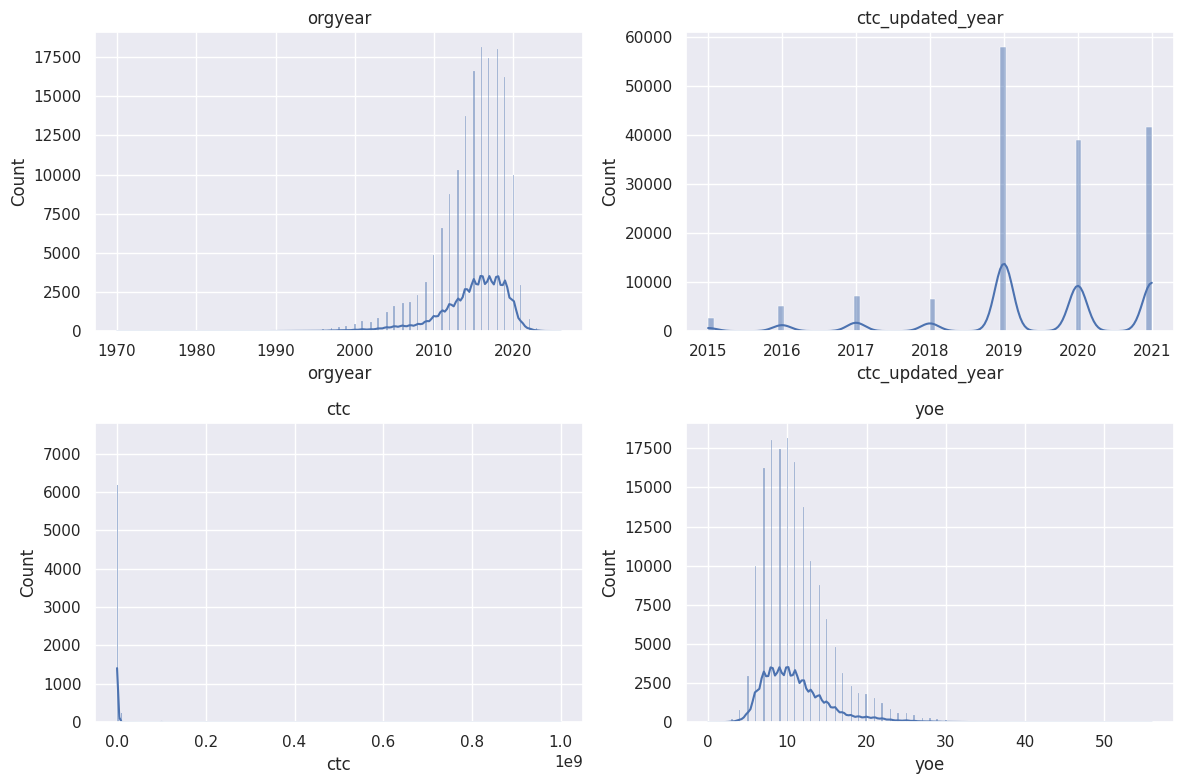

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numerical_col):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

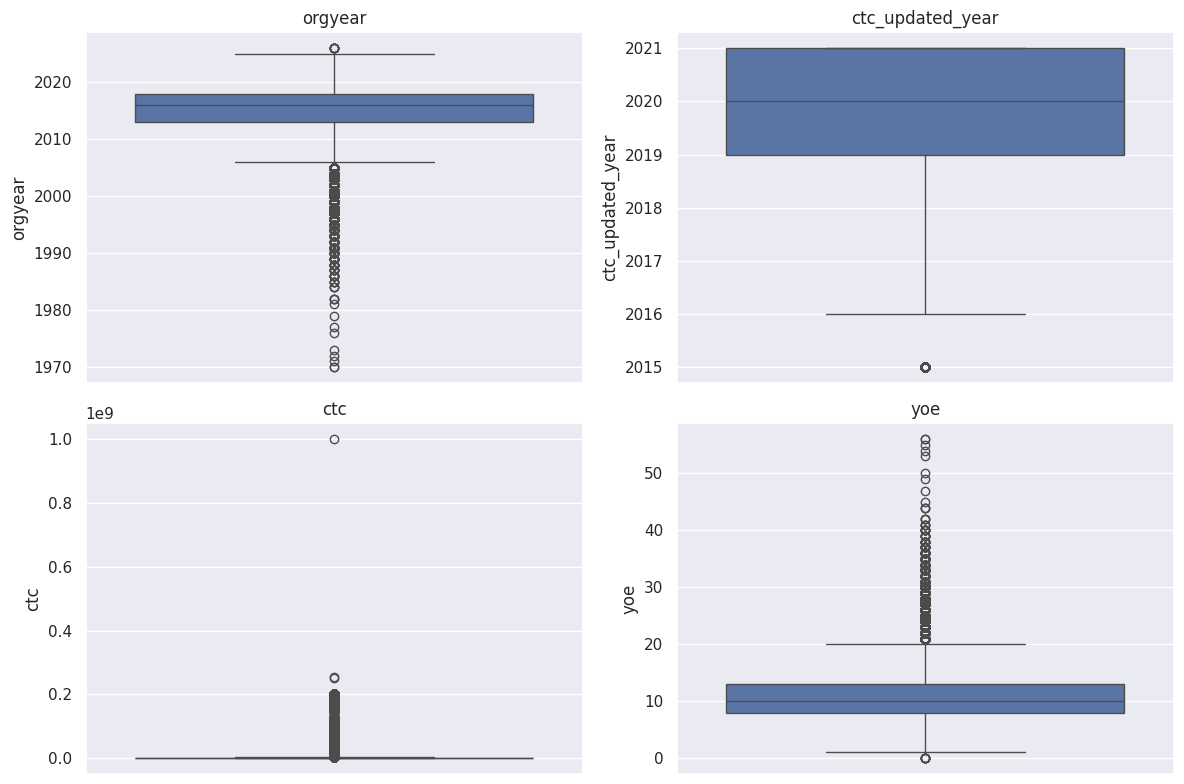

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numerical_col):
    sns.boxplot(data=df[col], ax=ax)
    ax.set_title(col)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

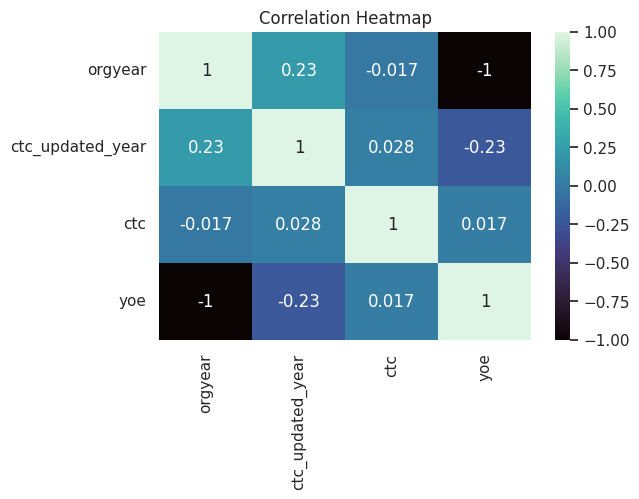

In [54]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[numerical_col].corr(), annot=True, cmap="mako")
plt.title("Correlation Heatmap")
plt.show()

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160438 entries, 0 to 160437
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   company_hash      160438 non-null  object
 1   email_hash        160438 non-null  object
 2   orgyear           160438 non-null  int64 
 3   ctc               160438 non-null  int64 
 4   job_position      160438 non-null  object
 5   ctc_updated_year  160438 non-null  int64 
 6   yoe               160438 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 8.6+ MB


In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
orgyear,160438.0,2.014893e+03,4.332901e+00,1970.0,2013.0,2016.0,2018.0,2.026000e+03
ctc,160438.0,2.471991e+06,1.286160e+07,2.0,550000.0,969999.0,1700000.0,1.000150e+09
ctc_updated_year,160438.0,2.019470e+03,1.354712e+00,2015.0,2019.0,2020.0,2021.0,2.021000e+03
yoe,160438.0,1.110694e+01,4.332901e+00,0.0,8.0,10.0,13.0,5.600000e+01


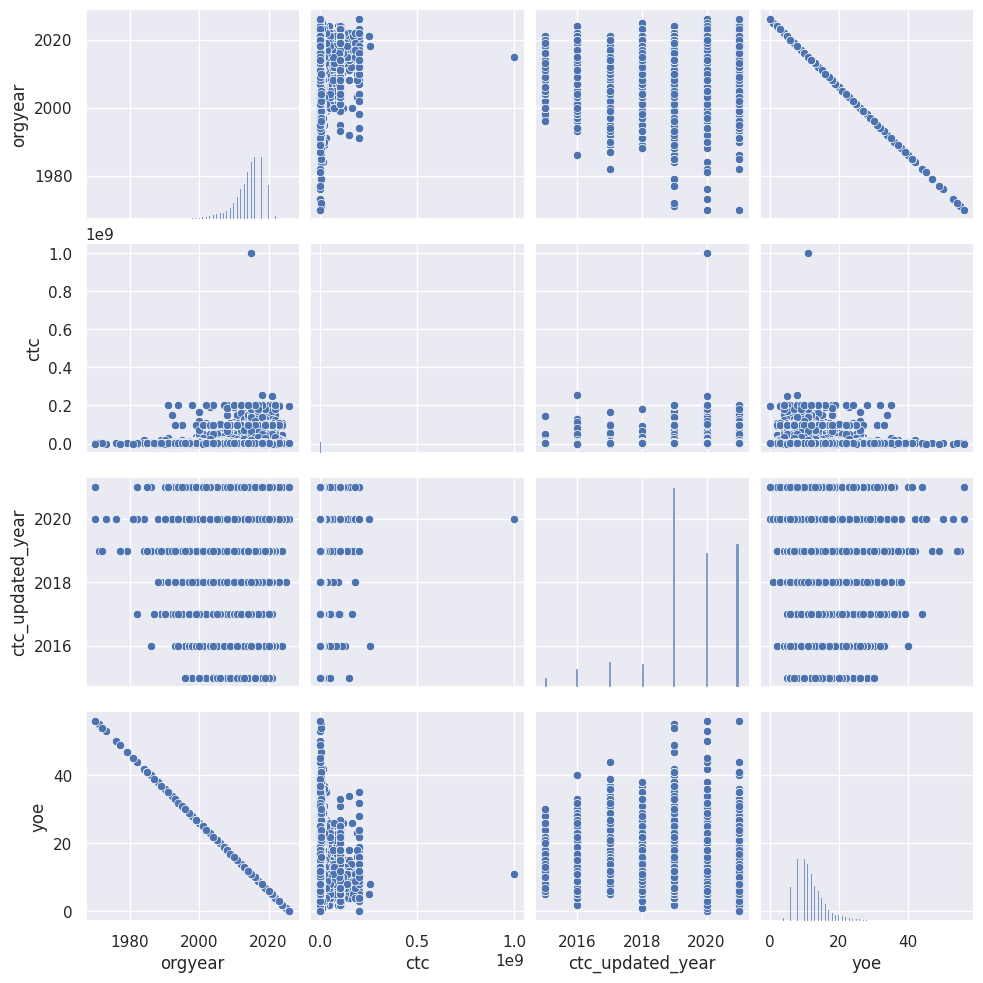

In [57]:
sns.pairplot(df)

In [58]:
result = []

for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    result.append([col, count])

outlier_df = pd.DataFrame(result, columns=['feature', 'outlier_count'])
outlier_df['percentage'] = outlier_df['outlier_count'] / len(df) * 100

outlier_df

,feature,outlier_count,percentage
0,orgyear,6625,4.129321
1,ctc_updated_year,2655,1.654845
2,ctc,10854,6.765230
3,yoe,6625,4.129321


Extremely low CTC values (single-digit or very small numbers) were identified as data errors due to unrealistic salary ranges. These records were removed as they could not be reliably corrected and would distort clustering results.


`ctc < 120k with yoe ≤ 1-2 -> likely interns/entry-level -> valid`

`ctc < 120k with yoe > 2 -> unrealistic -> noise`

In [59]:
df = df.loc[
    ~((df['ctc'] < 120000) & (df['yoe'] > 1))
].copy()

In [60]:
df.shape

(154937, 7)

In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
orgyear,154937.0,2.014909e+03,4.310705e+00,1970.0,2013.0,2016.0,2018.0,2.026000e+03
ctc,154937.0,2.557508e+06,1.307978e+07,42000.0,600000.0,1000000.0,1750000.0,1.000150e+09
ctc_updated_year,154937.0,2.019499e+03,1.333441e+00,2015.0,2019.0,2020.0,2021.0,2.021000e+03
yoe,154937.0,1.109104e+01,4.310705e+00,0.0,8.0,10.0,13.0,5.600000e+01


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154937 entries, 0 to 160437
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   company_hash      154937 non-null  object
 1   email_hash        154937 non-null  object
 2   orgyear           154937 non-null  int64 
 3   ctc               154937 non-null  int64 
 4   job_position      154937 non-null  object
 5   ctc_updated_year  154937 non-null  int64 
 6   yoe               154937 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 9.5+ MB


In [63]:
df['job_position'].unique()

array(['Backend Engineer', 'FullStack Engineer', 'Other',
       'Database Administrator', 'Frontend Engineer', 'SDET',
       'Product Designer', 'Support Engineer', 'Engineering Leadership',
       'Devops Engineer', 'Data Scientist', 'Data Analyst',
       'iOS Engineer', 'Engineering Intern', 'Research Engineers',
       'Product Manager', 'Applications Engineer', 'Fullstack Engineer',
       'Senior Applications Engineer', 'Release Engineer',
       'Program Manager', 'QA Engineer', 'Backend Architect',
       'Co-founder', 'Android Engineer', 'Security Leadership',
       'Associate Project Manager ', 'Software Development Engineer - I',
       'Consultant', 'SDE 3', 'Java Back End Developer', 'Non Coder',
       'Talent Acquisition Specialist',
       'Snr Analyst Programmer/Java Developer',
       'Senior Systems Engineer ', 'Business Man',
       'Senior Software Consultant',
       'Senior Associate - (Index Technology - Production Support)',
       'Marketing Professional ',

In [64]:
df['job_clean'] = df['job_position'].str.lower().str.strip().apply(lambda x: re.sub(r'[^a-z ]', '', x))

In [65]:
df['job_clean'].value_counts()

,count
job_clean,
other,36365
backend engineer,36127
fullstack engineer,23444
frontend engineer,9211
engineering leadership,6627
...,...
assistant engineer,1
software development,1
catagory manager,1


In [66]:
df['is_backend']   = df['job_clean'].str.contains('backend|back end')
df['is_frontend']  = df['job_clean'].str.contains('frontend|front end|ui')
df['is_fullstack'] = df['job_clean'].str.contains('fullstack|full stack')
df['is_data']      = df['job_clean'].str.contains('data|ml|machine learning|ai')
df['is_analyst']   = df['job_clean'].str.contains('analyst')
df['is_devops']    = df['job_clean'].str.contains('devops|sre|site reliability')
df['is_mobile']    = df['job_clean'].str.contains('android|ios|mobile')
df['is_test']      = df['job_clean'].str.contains('test|qa|sdet')

In [67]:
df['is_intern']  = df['job_clean'].str.contains('intern|trainee')
df['is_junior']  = df['job_clean'].str.contains('junior|jr')
df['is_senior']  = df['job_clean'].str.contains('senior|sr')
df['is_lead']    = df['job_clean'].str.contains('lead|principal|staff')
df['is_manager'] = df['job_clean'].str.contains('manager|head|director|cto')

In [68]:
df['is_engineer'] = df['job_clean'].str.contains('engineer|developer|sde')

In [69]:
df['is_valid_role'] = ~df['job_clean'].isin([
    'na', 'no', 'null', '', '.', '..'
])

In [70]:
def role_group(x):
    if 'data' in x or 'ml' in x:
        return 'data'
    elif 'backend' in x:
        return 'backend'
    elif 'frontend' in x:
        return 'frontend'
    elif 'fullstack' in x:
        return 'fullstack'
    elif 'android' in x or 'ios' in x:
        return 'mobile'
    elif 'devops' in x or 'sre' in x:
        return 'devops'
    elif 'analyst' in x:
        return 'analyst'
    elif 'manager' in x or 'lead' in x:
        return 'management'
    elif 'engineer' in x or 'developer' in x:
        return 'engineering'
    elif 'cto' in x or 'founder' in x:
        return 'chief'
    else:
        return 'other'

df['role_group'] = df['job_clean'].apply(role_group)

In [71]:
company_ctc_summary = (
    df.groupby('company_hash')['ctc']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

In [72]:
company_ctc_summary

,company_hash,count,mean,median,min,max
0,0000,1,300000.0,300000.0,300000,300000
1,01 fauzota,2,550000.0,550000.0,270000,830000
2,05gu bsuezknwe josvkwz nshswzc,1,1100000.0,1100000.0,1100000,1100000
3,1,1,250000.0,250000.0,250000,250000
4,1 azko,2,1180000.0,1180000.0,660000,1700000
...,...,...,...,...,...,...
35106,zzhjekfaf nwc,1,1526000.0,1526000.0,1526000,1526000
35107,zzhzqz fibw wzle,1,1000000.0,1000000.0,1000000,1000000
35108,zzm wzleuinitszf,1,800000.0,800000.0,800000,800000
35109,zzqansbz sul,1,710000.0,710000.0,710000,710000


In [73]:
job_ctc_summary = (
    df.groupby('job_position')['ctc']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

In [74]:
job_ctc_summary

,job_position,count,mean,median,min,max
0,.,1,700000.0,700000.0,700000,700000
1,..,1,600000.0,600000.0,600000,600000
2,.7,1,470000.0,470000.0,470000,470000
3,7,1,420000.0,420000.0,420000,420000
4,7033771951,1,100000000.0,100000000.0,100000000,100000000
...,...,...,...,...,...,...
875,software engineer 2B,1,1000000.0,1000000.0,1000000,1000000
876,student,1,1030000.0,1030000.0,1030000,1030000
877,support escalation engineer,1,2000000.0,2000000.0,2000000,2000000
878,system engineer,1,500000.0,500000.0,500000,500000


In [75]:
df.groupby('role_group')['ctc'].agg(['count','mean','median','min','max'])

,count,mean,median,min,max
role_group,,,,,
analyst,98,7.693571e+05,590000.0,140000,3100000
backend,37299,2.111459e+06,1250000.0,56000,200000000
chief,303,4.256607e+06,1300000.0,120000,200000000
data,7849,3.098565e+06,1000000.0,120000,200000000
devops,4175,1.677686e+06,1000000.0,120000,200000000
engineering,13549,2.482534e+06,700000.0,120000,200000000
frontend,9217,1.927792e+06,910000.0,42000,200000000
fullstack,23445,1.940153e+06,1000000.0,120000,200000000
management,8665,4.220125e+06,2510000.0,120000,200000000


In [76]:
yoe_ctc_summary = (
    df.groupby('yoe')['ctc']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

yoe_ctc_summary.sort_values(by='count', ascending=False).head()

,yoe,count,mean,median,min,max
10,10,17530,2.532414e+06,900000.0,120000,200000000
8,8,17398,2.087958e+06,750000.0,120000,255555555
9,9,16769,2.287150e+06,800000.0,120000,200000000
11,11,16108,2.611325e+06,960000.0,120000,1000150000
7,7,15903,1.893075e+06,700000.0,120000,200000000


In [ ]:
df.groupby(['company_hash', 'role_group', 'yoe'])['ctc'].agg(['count', 'mean', 'median', 'min', 'max'])

count       mean     median  \
company_hash                   role_group yoe                                
0000                           other      9        1   300000.0   300000.0   
01 fauzota                     frontend   15       1   830000.0   830000.0   
                               mobile     10       1   270000.0   270000.0   
05gu bsuezknwe josvkwz nshswzc backend    7        1  1100000.0  1100000.0   
1                              other      4        1   250000.0   250000.0   
...                                              ...        ...        ...   
zzhjekfaf nwc                  mobile     14       1  1526000.0  1526000.0   
zzhzqz fibw wzle               frontend   15       1  1000000.0  1000000.0   
zzm wzleuinitszf               devops     10       1   800000.0   800000.0   
zzqansbz sul                   fullstack  9        1   710000.0   710000.0   
zzqaukdrkos                    mobile     13       1  2400000.0  2400000.0   

                                                   min      max  
company_hash                   role_group yoe                    
0000                           other      9     300000   300000  
01 fauzota                     frontend   15    830000   830000  
                               mobile     10    270000   270000  
05gu bsuezknwe josvkwz nshswzc backend    7    1100000  1100000  
1                              other      4     250000   250000  
...                                                ...      ...  
zzhjekfaf nwc                  mobile     14   1526000  1526000  
zzhzqz fibw wzle               frontend   15   1000000  1000000  
zzm wzleuinitszf               devops     10    800000   800000  
zzqansbz sul                   fullstack  9     710000   710000  
zzqaukdrkos                    mobile     13   2400000  2400000  

[87351 rows x 5 columns]

#Manual Clustering

In [ ]:
group_cols = ['company_hash', 'role_group', 'yoe']
group_avg = (
    df.groupby(group_cols)['ctc']
    .mean()
    .reset_index()
    .rename(columns={'ctc': 'group_avg_ctc'})
)

df = df.merge(group_avg, on=group_cols, how='left')

for designation:

3 -> Underpaid vs peers

2 -> Fairly paid

1 -> Overpaid / high performer

In [ ]:
def assign_flag(row):
    avg = row['group_avg_ctc']

    if row['ctc'] < 0.9 * avg:
        return 3   # underpaid
    elif row['ctc'] > 1.1 * avg:
        return 1   # overpaid
    else:
        return 2   # average

df['designation'] = df.apply(assign_flag, axis=1)

for class:

3 -> Underpaid vs same company + role

2 -> Around average

1 -> Above average

In [ ]:
group_cols = ['company_hash', 'role_group']
group_avg = (
    df.groupby(group_cols)['ctc']
    .mean()
    .reset_index()
    .rename(columns={'ctc': 'group_avg_ctc_role'})
)

df = df.merge(group_avg, on=group_cols, how='left')

df['Class'] = np.where(
    df['ctc'] < 0.9 * df['group_avg_ctc_role'], 3,
    np.where(
        df['ctc'] > 1.1 * df['group_avg_ctc_role'], 1,
        2
    )
)

for tiers:

3 -> Low earner within company

2 -> Around earner

1 -> High earners

In [ ]:
company_avg = (
    df.groupby('company_hash')['ctc']
    .mean()
    .reset_index()
    .rename(columns={'ctc': 'company_avg_ctc'})
)

df = df.merge(company_avg, on='company_hash', how='left')

df['Tier'] = np.where(
    df['ctc'] < 0.9 * df['company_avg_ctc'], 3,
    np.where(
        df['ctc'] > 1.1 * df['company_avg_ctc'], 1,
        2
    )
)

In [ ]:
df[['designation', 'Class', 'Tier']].apply(pd.Series.value_counts)

,designation,Class,Tier
1,23156,27620,27315
2,88070,56449,40292
3,43711,70868,87330


In [ ]:
pd.crosstab(df['designation'], df['Class'])

Class,1,2,3
designation,,,
1,12429,3638,7089
2,14097,50803,23170
3,1094,2008,40609


In [ ]:
pd.crosstab(df['Class'], df['Tier'])

Tier,1,2,3
Class,,,
1,18092,4078,5450
2,7879,33774,14796
3,1344,2440,67084


In [ ]:
pd.crosstab(df['designation'], df['Tier'])

Tier,1,2,3
designation,,,
1,9215,3499,10442
2,17064,35369,35637
3,1036,1424,41251


# Insights base on : Designation, Class, Tier

The three flags capture **relative earning position at different levels**:

- **Designation** : global peer comparison  
- **Class** : company + role comparison  
- **Tier** : company-wide comparison  

---

## High Underpaid Population (at Global Level)

- **Designation = 3 (Underpaid globally)** has the high count (~43K)
- Many of these also fall into:
  - **Class = 3 (underpaid within role)**
  - **Tier = 3 (low earners in company)**

Insight:
> A significant portion of learners are consistently underpaid across all benchmarks.

---

##Majority Are "Average"

- **Class = 2 (around role average)** is dominant (~56K)
- But many of them fall into:
  - **Tier = 2 or 3**

Insight:
> Even when paid fairly within role, company-level compensation may still be suboptimal.

---

## True High Performers Are Limited

- **Designation = 1 (top performers globally)** are fewer (~23K)
- Among them:
  - Majority fall into **Class = 1**
  - Also align with **Tier = 1**

Insight:
> High performers are consistently rewarded.

---

## Most Critical Segment

From cross tables:

- High count of:
  - **Designation = 3**
  - **Class = 3**
  - **Tier = 3**

Insight:
> This is the **most vulnerable group**:
- underpaid globally  
- underpaid within role  
- underpaid within company  


##Top 10 employees (earning more than most of the employees in the company) - Tier 1

In [ ]:
top_earners = df[df['Tier'] == 1]
top_10 = (
    top_earners
    .sort_values(by='ctc', ascending=False)
    .head(10)
)

top_10[['email_hash', 'company_hash', 'ctc', 'role_group', 'yoe']].head(10)

,email_hash,company_hash,ctc,role_group,yoe
55250,5b4bed51797140db4ed52018a979db1e34cee49e27b488...,fhkowjosylih,255555555,other,8
55193,5b326888dd18482c9ddd709467798c5aad5c36b21a9112...,gkpkp kdwi nwc,200000000,management,8
99815,a4f205709a7fb81695c001bc60005f982f137a9c681192...,wkwk kcvkulzc fafwzhf,200000000,other,9
14712,17d7a7983d8f944459e2d114a99f68634447e552f7aff0...,kcf findwsiu,200000000,other,9
31415,33bcb071ff81ffdff70a614fd0e6c51c7d27edac338a40...,knwoku,200000000,frontend,14
54525,5a22951df9377bc13dab9bd4771ee7d0bbd7e639d2f81b...,iwezo,200000000,frontend,11
54669,5a62c4492a39b13d825bdd372b9891103252b816818b43...,subifaf,200000000,other,15
41762,451d6f9e11a60010f0175bbe467a8de3b1a899d4d2f2a2...,efgl,200000000,other,11
124224,cd5ad9fdddd2d07a0cded3a808880c937292191a57ca85...,fwkowdj,200000000,other,9
68826,71d7605911c92225343efc7e8aa1a81b60b5ed81796318...,msjoi nshswzc,200000000,frontend,8


##Top 10 employees of data science in each company earning more than their peers - Class 1

In [ ]:
top_10_per_company = (
    df[
    (df['role_group'] == 'data') &
    (df['Class'] == 1)]
    .sort_values(by='ctc', ascending=False)
    .groupby('company_hash')
    .head(10)
)

top_10_per_company[['company_hash', 'email_hash', 'ctc', 'yoe', 'job_position']].head(10)

,company_hash,email_hash,ctc,yoe,job_position
8717,eln wzleuinitszf,0df461881c039e7d8fa8db9b24f28ff190c74fed483594...,200000000,14,Database Administrator
73961,wzle hkesucok,7a723f5b71698674b79bd2195c3bb58d3fcbf4ddb75a04...,200000000,7,Data Analyst
148811,filsw tuoknz,f5b2a30853a67e1703249db6003884d7e1ae69e0c03aa0...,200000000,12,Data Analyst
53940,wkwk liufdnwkula fzovslzf,59316048d113539202325e05af9b66620255ba84eab635...,200000000,11,Data Analyst
90633,khkqiu,95c8bdd3d10f967f6bfb32f280b0b37fbf5db2359918ba...,200000000,10,Data Analyst
103413,litusqkuw,aad581a532f319c76c6e73937572feed9867d5ee2f1093...,200000000,12,Data Analyst
124407,gosfwnzliuz k hkesucok toidj lihjkua,cda8d723438e81185d2ee8c348870a4612eea974cdb2db...,200000000,9,Data Scientist
32714,ogf,35d4845547c5d2e0c2eadc197c97c678035bceb5fddd2d...,200000000,11,Data Analyst
80569,ozbsuswsv,853731bca9459bfff54bf61518885293a0f4a8bef6fca6...,200000000,8,Data Analyst
94965,liucdzuw,9ce2995b2221fe627e861daea9d0603872cce8cc128390...,200000000,10,Data Analyst


##Bottom 10 employees of data science in each company earning less than their peers - Class 3

In [ ]:
bottom_10_per_company = (
    df[(df['role_group'] == 'data') & (df['Class'] == 3)]
    .sort_values(by='ctc', ascending=True)  # lowest first
    .groupby('company_hash')
    .head(10)
)

bottom_10_per_company[['company_hash', 'email_hash', 'ctc', 'yoe', 'job_position']].head(10)

,company_hash,email_hash,ctc,yoe,job_position
128335,kjjnz,d413bb8062c7d1562c2f9d6ef1bef106e68a4b75abdfc8...,120000,12,Data Scientist
137247,wez fjkorf biduckwsiu,e2d2037485674912117ed932a201f05167f37224a0c0d0...,120000,7,Data Analyst
6535,litusqkuw,0a64396c6529260a084e8b8fa8b6abdceb5aa1d46cb100...,120000,23,Data Scientist
72007,uiw kjjnslkgnz klliduw,77385839bb073bbc733613403b8cf04f507c8615959bfe...,120000,5,Data Analyst
106202,fwdczuw,af68ec02d3af675a24cec50cf07964ae68a68937b661fe...,120000,5,Data Scientist
114655,hkx fibwmkoz,bd67e3d92cc45815eccfb07db225e1a94f427e1ace51e3...,120000,6,Data Scientist
109621,jkajkn,b4f85088ce3923aa308fe6ac54725f42f5270ef9191b15...,124000,17,Data Scientist
141333,lkjtzhsus,e99e8467e1792c95a09aee78a4c1cd4258bfc4c4755760...,125000,8,Data Scientist
22117,xdknlihh,2424f5ffca81a84890e25ff3e635ffc3b9222d7d36766c...,125000,8,Data Scientist
17263,znzlwoiusl kowf zk,1c16a1c852281ffec94c8c4721440d5f5caa009a9de8a6...,125000,13,Data Analyst


##Bottom 10 employees (earning less than most of the employees in the company)- Tier 3

In [ ]:
bottom_10_per_company = (
    df[df['Tier'] == 1]
    .sort_values(by='ctc', ascending=True)  # lowest salaries first
    .groupby('company_hash')
    .head(10)
)

bottom_10_per_company[['company_hash', 'email_hash', 'ctc', 'yoe', 'job_position']].head(10)

,company_hash,email_hash,ctc,yoe,job_position
53614,lihlkfw lkgnz,58a672fa82ea864f13e0e2941641c6f569c58e54a5ee2a...,151000,19,Other
83286,jndhsul,89c50595727487bfa7d687bb168d2c2b55a57646876a4d...,155000,9,Data Scientist
125692,fdovzahiurza,cfc85e9278318bc97bd994ed23681c3c9abeb61915f91e...,170000,22,Backend Engineer
40749,kvkukcz,4353cb4b9aad088dd843eca4f270d7af60f53e5f740be4...,177000,26,FullStack Engineer
116965,biffsn,c15468e047f7c3d7f116e4585efcb3cb10c0836cea8d67...,180000,9,Backend Engineer
76202,mionc lozcsw fkvsutf nshswzc,7e1e3a27d8685d3c5eca526712cd93a3ae872ba5e7a230...,183000,16,FullStack Engineer
104231,lkokcsth k tz ezknwelkoz lihjkua,ac25f96af8c45fb7c530b84909abab39a5c8fceaa6a742...,190000,22,Other
8469,ihuswszo sul,0d88d817c886b010165c3aa31cda1cfc61bafef98368ce...,200000,15,Backend Engineer
57438,fmsbw,5ee70a2bcb186474df8534d2b106aead83e96ede407f90...,200000,22,Backend Engineer
4241,fshjnz boklwkn,06d634aab2ac8c7c6ba219b1ad58e7646068cda6a112fa...,200000,9,FullStack Engineer


##Top 10 companies (based on their CTC)

In [ ]:
top_companies = (
    df.groupby('company_hash')['ctc']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_companies

,company_hash,ctc
0,ldgsl nitslf josvkwz nshswzc,1.000150e+09
1,ckbbicsn suwzoukwsiukn dusvzofswa,2.500000e+08
2,nitsl zoj,2.000000e+08
3,pks ukokaku wokczof jvw nwc,2.000000e+08
4,nkgces nsbzfwanz nshswzc,2.000000e+08
5,kcessjk wzleuinitszf jvw nwc,2.000000e+08
6,crkwsk,2.000000e+08
7,fzi zyzldwsvz,2.000000e+08
8,usfekuw lihjdwzof,2.000000e+08
9,biy u lnidc wzleuinitszf,2.000000e+08


In [ ]:
top_companies = (
    df.groupby('company_hash')['ctc']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

top_companies

,ctc
company_hash,
ldgsl nitslf josvkwz nshswzc,1.000150e+09
ckbbicsn suwzoukwsiukn dusvzofswa,2.500000e+08
lnslriulkoz ozwksn jvw nwc,2.000000e+08
smior wzleuinitszf,2.000000e+08
fiuk linnztz ib wzleuinitakuuk dusvzofswa,2.000000e+08
iogsw fibwmkoz sul,2.000000e+08
sldgz findwsiuf,2.000000e+08
wzleuijkor swokswq sw findwsiu,2.000000e+08
losllndgf,2.000000e+08


##Top 2 positions in every company (based on their CTC)

In [ ]:
role_ctc = (
    df.groupby(['company_hash', 'role_group'])['ctc']
    .mean()
    .reset_index()
)

top_roles = (
    role_ctc
    .sort_values(['company_hash', 'ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(2)
)

top_roles

,company_hash,role_group,ctc
0,0000,other,300000.0
1,01 fauzota,frontend,830000.0
2,01 fauzota,mobile,270000.0
3,05gu bsuezknwe josvkwz nshswzc,backend,1100000.0
4,1,other,250000.0
...,...,...,...
52865,zzhjekfaf nwc,mobile,1526000.0
52866,zzhzqz fibw wzle,frontend,1000000.0
52867,zzm wzleuinitszf,devops,800000.0
52868,zzqansbz sul,fullstack,710000.0


##Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X

In [ ]:
def top_employees(
    df,
    role='data',            # X department
    yoe_list=[5,6,7],       # experience filter
    tier=None               # e.g., 1 for high-paying companies, or None
):
    temp = df[
        (df['role_group'] == role) &
        (df['yoe'].isin(yoe_list)) &
        (df['Class'] == 3)   # earning more than peers
    ]

    if tier is not None:
        temp = temp[temp['Tier'] == tier]

    result = (
        temp
        .sort_values(by='ctc', ascending=False)
        .groupby('company_hash')
        .head(10)
    )

    return result

In [ ]:
top_employees(df, role='data', yoe_list=[5,6,7], tier=3)[['company_hash', 'email_hash', 'ctc', 'yoe', 'role_group']]

,company_hash,email_hash,ctc,yoe,role_group
150686,tiitnz,f8c5a8802297e94f97356e99b8c46228f72e5c012b1cff...,3800000,5,data
95861,filsw tuoknz,9e5edb6c6ab885938b9a85388e13726f6bfa25ec829fed...,3550000,7,data
50676,uiw kjjnslkgnz klliduw,53ef1ea78c11011509cb03cb87e0018b552cfdadeda2d0...,2400000,6,data
36883,bokurnsu wzhjnzwiu suvzfwhzuwf,3cc98cb22ea2adee5465ad51600f48856f2503a76697fe...,2300000,7,data
58017,lsws,5fbe24acd2a3e16a514bbe597dcbb7ec27ff9b675660dd...,2200000,6,data
...,...,...,...,...,...
16050,wkwk lihhduslkwsiuf,1a1aa3eaf4e13a56c6f24cdbfb84b0399c363b84e82cba...,170000,6,data
25753,nimzf lihjkuszf sul,2a310b724a62c1c84d62b4ca17c015007884e1802befb2...,145000,6,data
114655,hkx fibwmkoz,bd67e3d92cc45815eccfb07db225e1a94f427e1ace51e3...,120000,6,data
106202,fwdczuw,af68ec02d3af675a24cec50cf07964ae68a68937b661fe...,120000,5,data


In [ ]:
top_employees(df, role='backend', yoe_list=[5,6,7])[['company_hash', 'email_hash', 'ctc', 'yoe', 'role_group']]

,company_hash,email_hash,ctc,yoe,role_group
74744,vsowdfk,7bc03fab0706d0b9430cf14812abb796917d3f0fc99b57...,4400000,6,backend
12538,fwdczuw,1422467050115a190eef2eb7be2e0ba3d6e69479add76d...,3600000,7,backend
74946,fwdczuw,7c16814358f35643107efba3fdaca1efe8eb648b2df58d...,3570000,7,backend
111536,tiitnz,b81d50528b362e47b593e6ca1e0108631897ea3c54c8f7...,3500000,7,backend
81518,fwdczuw,86c80784895f30f5c195339e4b89d8e2354142157a1e24...,3400000,7,backend
...,...,...,...,...,...
9716,oigzow gifle zutsuzzosut kuc gdfsuzff findwsiuf,0f982249a0d80eeb52662a66e35aec66ffcd2076facd30...,140000,7,backend
26708,subiohkwslk,2bc3b1e9301c2bb4d0edcb89d8b0950f4ba51734c74b1a...,140000,6,backend
19751,cznn zhl,204f64dc6ca7b4c3bab3579cb0788b7e5ec564bf86b135...,130000,7,backend
14749,linnkgzok sul,17e7df2a2d5b9cff2c2436de42592626611dfbb01c910e...,125000,7,backend


#Model Building

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year', 'yoe', 'job_clean', 'is_backend', 'is_frontend',
       'is_fullstack', 'is_data', 'is_analyst', 'is_devops', 'is_mobile',
       'is_test', 'is_intern', 'is_junior', 'is_senior', 'is_lead',
       'is_manager', 'is_engineer', 'is_valid_role', 'role_group',
       'group_avg_ctc', 'designation', 'group_avg_ctc_role', 'Class',
       'company_avg_ctc', 'Tier'],
      dtype='object')

In [ ]:
df['last_ctc_update'] = 2026 - df['ctc_updated_year']

In [ ]:
np.sum(df['last_ctc_update'] < 0)

np.int64(0)

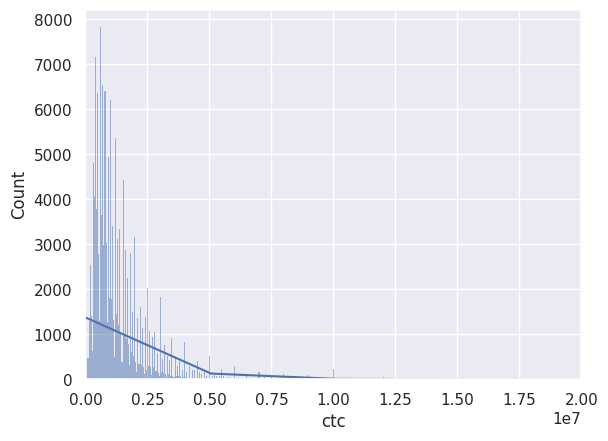

In [ ]:
sns.histplot(data=df, x='ctc', kde=True)
plt.xlim(0, 20000000)
plt.show()

In [ ]:
X = df[['ctc', 'yoe', 'is_backend', 'is_frontend', 'is_fullstack', 'is_data','is_analyst', 'is_devops', 'is_mobile', 'is_test', 'is_intern','is_senior', 'is_manager', 'role_group', 'designation', 'Class', 'Tier', 'last_ctc_update']].copy(deep = True)

In [ ]:
X = pd.get_dummies(X, columns=['role_group'], drop_first=True)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154937 entries, 0 to 154936
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   ctc                     154937 non-null  int64
 1   yoe                     154937 non-null  int64
 2   is_backend              154937 non-null  bool 
 3   is_frontend             154937 non-null  bool 
 4   is_fullstack            154937 non-null  bool 
 5   is_data                 154937 non-null  bool 
 6   is_analyst              154937 non-null  bool 
 7   is_devops               154937 non-null  bool 
 8   is_mobile               154937 non-null  bool 
 9   is_test                 154937 non-null  bool 
 10  is_intern               154937 non-null  bool 
 11  is_senior               154937 non-null  bool 
 12  is_manager              154937 non-null  bool 
 13  designation             154937 non-null  int64
 14  Class                   154937 non-null  int64
 15  

<Axes: >

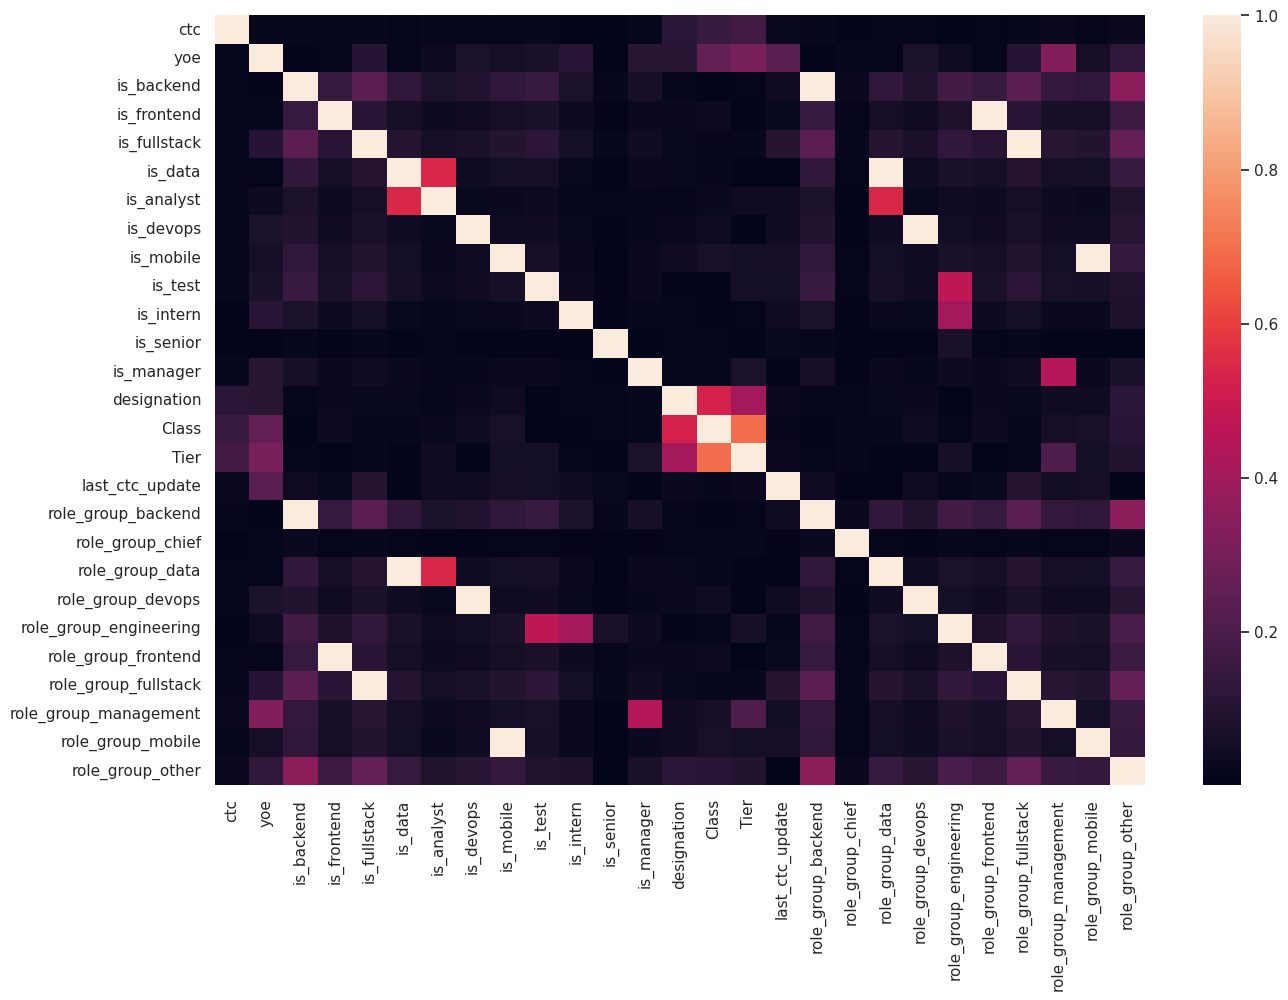

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(X.corr().abs())

In [ ]:
rem_cols = ['is_backend', 'is_fullstack','is_mobile','is_devops', 'is_data', 'is_frontend']

X.drop(columns=rem_cols, inplace=True)

<Axes: >

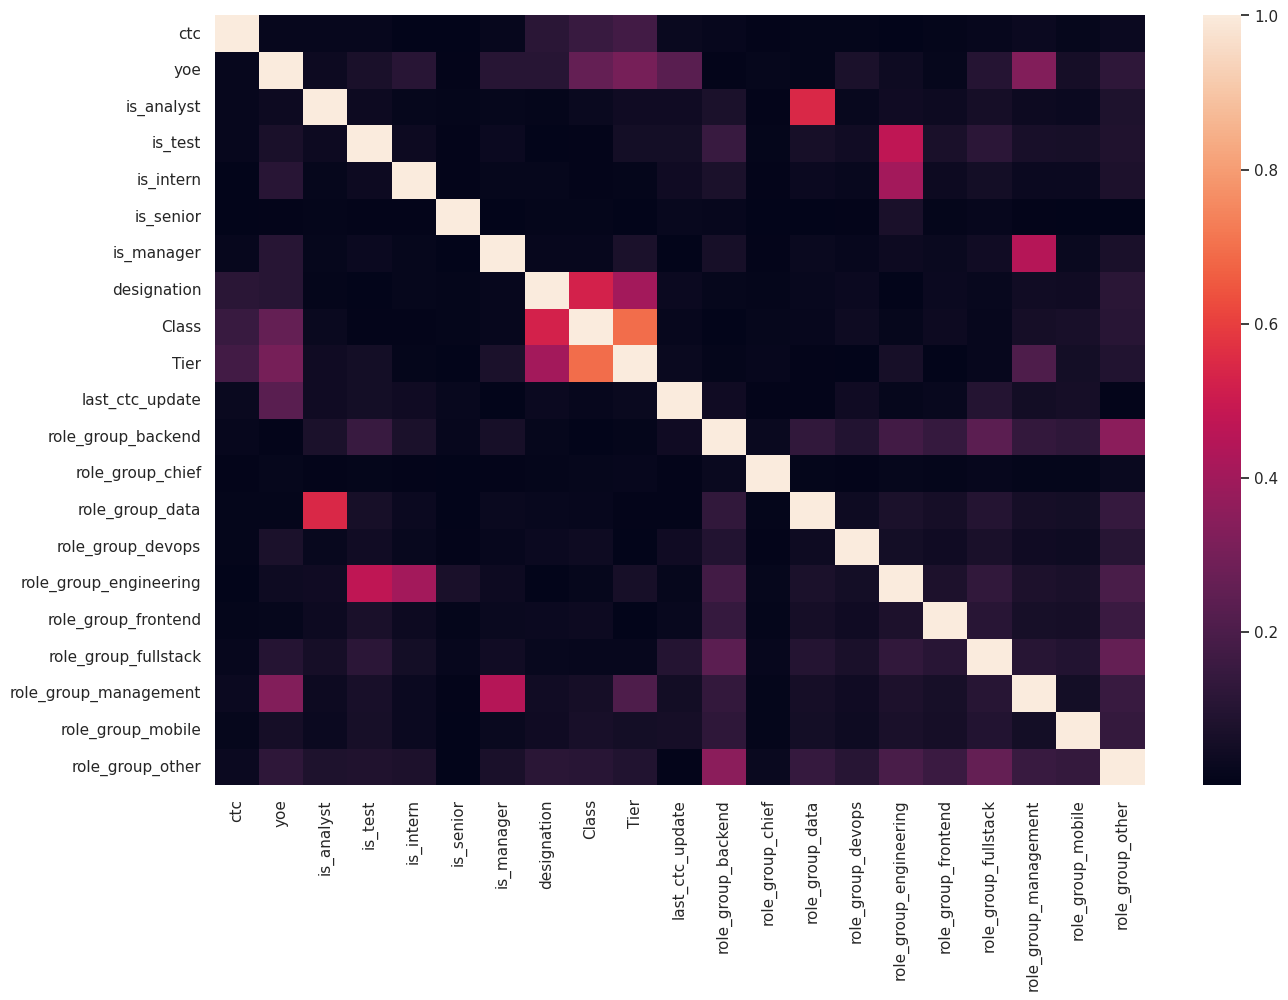

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(X.corr().abs())

In [ ]:
X.columns

Index(['ctc', 'yoe', 'is_analyst', 'is_test', 'is_intern', 'is_senior',
       'is_manager', 'designation', 'Class', 'Tier', 'last_ctc_update',
       'role_group_backend', 'role_group_chief', 'role_group_data',
       'role_group_devops', 'role_group_engineering', 'role_group_frontend',
       'role_group_fullstack', 'role_group_management', 'role_group_mobile',
       'role_group_other'],
      dtype='object')

In [ ]:
X['ctc'] = np.log1p(X['ctc'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

#Visualtization(PCA, t-SNE)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

import plotly.express as px

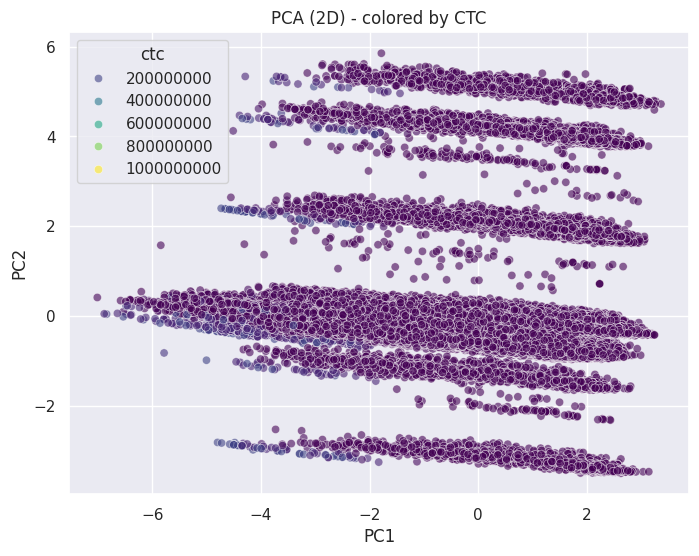

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['ctc'] = df['ctc'].values
pca_df['yoe'] = df['yoe'].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='ctc', palette='viridis', alpha=0.6)
plt.title("PCA (2D) - colored by CTC")
plt.show()

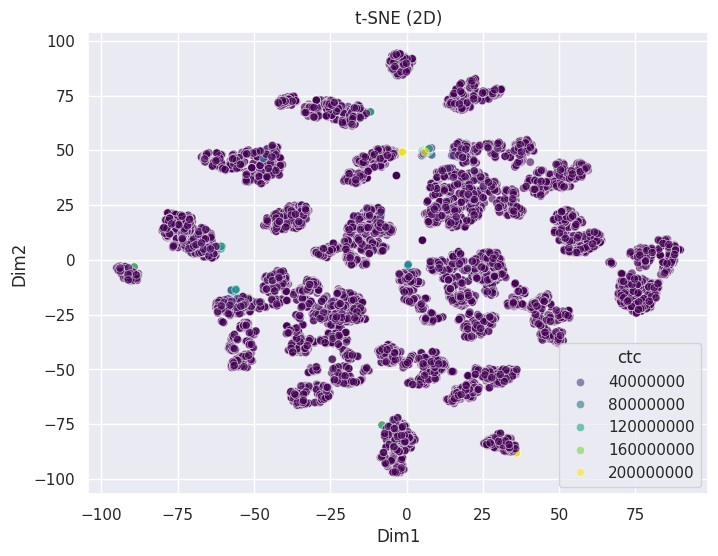

In [ ]:
sample_idx = np.random.choice(len(X), 15000, replace=False)
X_sample = X[sample_idx]

tsne = TSNE(n_components=2, perplexity=70, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame(X_tsne, columns=['Dim1','Dim2'])
tsne_df['ctc'] = df.iloc[sample_idx]['ctc'].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='ctc', palette='viridis', alpha=0.6)
plt.title("t-SNE (2D)")
plt.show()

umap without the flags i.e. only with these features 'ctc', 'yoe', 'designation', 'Class', 'Tier', 'last_ctc_update'

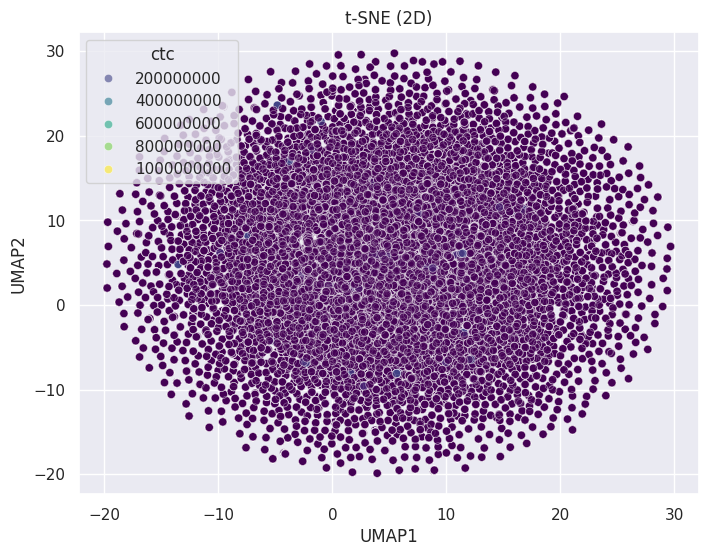

In [ ]:
# import umap.umap_ as umap
# X_pca_10 = PCA(n_components=10).fit_transform(X)

umap_model = umap.UMAP(n_components=2, init='random')
X_umap = umap_model.fit_transform(X[:,[0, 1, 7, 8, 9, 10]])

umap_df = pd.DataFrame(X_umap, columns=['UMAP1','UMAP2'])
umap_df['ctc'] = df['ctc'].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='ctc', palette='viridis', alpha=0.6)
plt.title("t-SNE (2D)")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


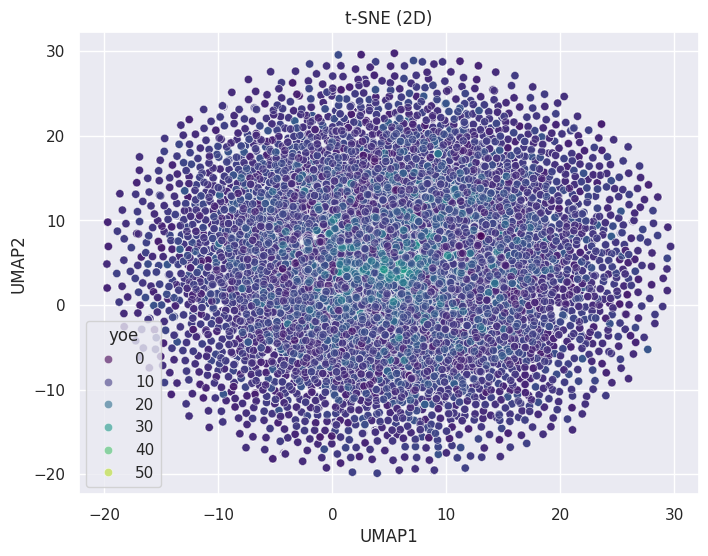

In [ ]:
umap_df['yoe'] = df['yoe'].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='yoe', palette='viridis', alpha=0.6)
plt.title("t-SNE (2D)")
plt.show()

#Kmeans

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

K_range = range(2,15)  # silhouette needs at least 2 clusters
inertia = []
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))


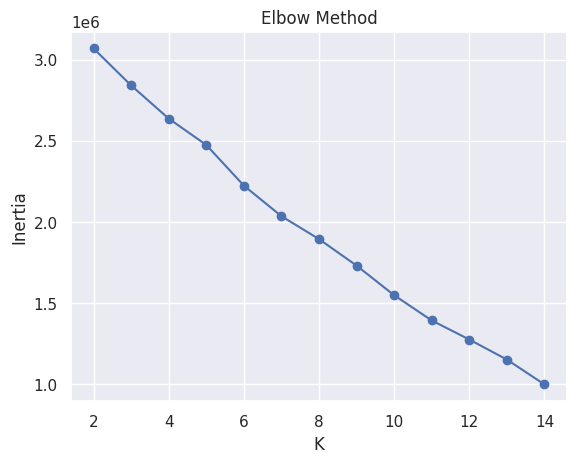

In [ ]:
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

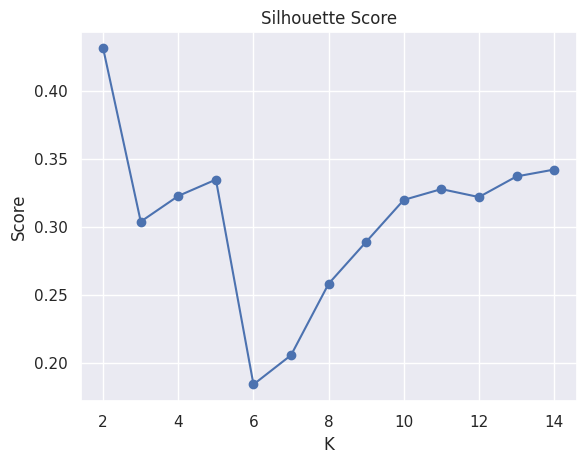

In [ ]:
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

While k=2 gives the highest silhouette score, it results in overly coarse segmentation. A value of k=5 was selected as a trade-off between cluster quality and interpretability, enabling meaningful segmentation across roles, experience levels, and compensation tiers. At k = 14, it seems i finds lots of micro clusters but duw to interpretebility i am going with k = 5

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit + predict
clusters = kmeans.fit_predict(X)
df['k_means_cluster'] = clusters
df['k_means_cluster'].value_counts()

,count
k_means_cluster,
1,137006
2,8684
4,4175
3,2603
0,2469


In [ ]:
summary = df.groupby('k_means_cluster').agg({
    'ctc': 'mean',
    'yoe': 'mean',
    'last_ctc_update': 'mean',
    'designation': 'mean',
    'Class': 'mean',
    'Tier': 'mean'
})

summary

,ctc,yoe,last_ctc_update,designation,Class,Tier
k_means_cluster,,,,,,
0,2.211365e+06,7.432564,6.941677,2.053463,2.243418,2.454435
1,2.445107e+06,10.751624,6.472848,2.143848,2.293235,2.421930
2,4.257020e+06,16.936550,6.778328,2.015431,2.100875,1.745739
3,4.543273e+06,9.966577,6.088744,2.187476,2.433730,2.631195
4,1.677686e+06,12.935090,6.837365,2.022275,2.111856,2.395449


# Learner Clustering Insights (KMeans, k=5)

## Overview
KMeans clustering (k=5) was applied on engineered features including compensation (CTC), years of experience (YOE), role indicators, and company-level signals.

The model achieved a **Silhouette Score ≈ 0.34**, indicating **moderate cluster separation**, which is expected in real-world career data where segments naturally overlap.

---

# Cluster Statistics

| Cluster | Avg CTC (₹) | Avg YOE | Last CTC Update | Designation | Class | Tier |
|--------|------------|--------|----------------|------------|-------|------|
| 0 | 22.1 LPA | 7.43 | 6.94 | 2.05 | 2.24 | 2.45 |
| 1 | 24.5 LPA | 10.75 | 6.47 | 2.14 | 2.29 | 2.42 |
| 2 | 42.6 LPA | 16.94 | 6.78 | 2.02 | 2.10 | 1.75 |
| 3 | 45.4 LPA | 9.97 | 6.08 | 2.19 | 2.43 | 2.63 |
| 4 | 16.7 LPA | 12.93 | 6.84 | 2.02 | 2.11 | 2.39 |

---

# Cluster-wise Interpretation

## Cluster 0 — Mid-Level Stable Engineers
- Moderate experience (~7 yrs)
- Stable compensation (~22 LPA)
- Mid-tier companies

**Insight:**  

    Balanced professionals with steady growth.

---

## Cluster 1 — Senior but Moderately Paid
- High experience (~10.7 yrs)
- Only slightly higher pay(24.5 LPA) than Cluster 0

**Insight:**  

    Salary growth is slower than expected -> **stagnation risk**

---

## Cluster 2 — Veteran Underpaid Professionals
- Highest experience (~17 yrs)
- High salary (~42 LPA) but **lowest company tier**

**Insight:**  

    Experienced professionals in weaker-paying companies.

    *Prime candidates for job switch -> high upside potential*

---

## Cluster 3 — High-Performing Elite Group
- High salary (~45 LPA)
- Moderate experience (~10 yrs)
- Highest company tier

**Insight:**  
    
    Top talent working in premium companies.

    *Best-performing segment*

---

## Cluster 4 — Experienced but Underpaid
- High experience (~13 yrs)
- Lowest salary (~16.7 LPA)

**Insight:**  

    Severely underpaid workforce.

    *Critical segment for intervention*

---

#Key Observations

## 1. Experience != Salary
- Cluster 2 & 4 show high experience but not highest compensation
- Salary depends on **company and role, not just experience**

---

## 2. Company Tier Drives Salary
- Cluster 3 earns more than Cluster 2 despite lower experience

- *Company quality > experience*

---

## 3. Underpaid Segments Exist
- Cluster 4 -> severely underpaid  
- Cluster 1 -> moderately underpaid  

- Indicates **market inefficiency**

---

# Business Implications

- **Learner Profiling:** Identify high-growth vs stagnant professionals  
- **Career Guidance:** Recommend company switches for underpaid clusters  
- **Hiring Strategy:** Target Cluster 2 & 4 for high ROI hiring  
- **Salary Benchmarking:** Use clusters to detect compensation gaps  

---

The clustering reveals:
- **Natural segmentation exists but is overlapping**
- Compensation is strongly influenced by **company tier**
- Significant population of **underpaid professionals** exists

Despite moderate silhouette score, the clusters provide **actionable real-world insights** for both learners and companies.

In [ ]:
company_cluster_dist = df.groupby('company_hash')['k_means_cluster'] \
    .value_counts(normalize=True) \
    .unstack(fill_value=0)

company_cluster_dist.sample(10)

k_means_cluster,0,1,2,3,4
company_hash,,,,,
jnkuzwjnkuf,0.0,1.000000,0.000000,0.000000,0.000000
kkrkfe wzywsnz zutsuzzof nnj,0.0,1.000000,0.000000,0.000000,0.000000
knnasi,0.0,1.000000,0.000000,0.000000,0.000000
kbifzovz,0.0,1.000000,0.000000,0.000000,0.000000
ezmnzww jklrkoc sucsk,0.0,1.000000,0.000000,0.000000,0.000000
finlzu wzleuinita,0.0,1.000000,0.000000,0.000000,0.000000
hzwoslfwozkh,0.0,0.944444,0.027778,0.013889,0.013889
tnigkntaku jvw nwc,0.0,1.000000,0.000000,0.000000,0.000000
tsosriu findwsiu jvw nwc,0.0,1.000000,0.000000,0.000000,0.000000


In [ ]:
persona_map = {
    0: "Mid-Level Stable",
    1: "Senior but Stagnating",
    2: "Veteran Underpaid",
    3: "Elite High Performer",
    4: "Experienced but Underpaid"
}

df['k_means_persona'] = df['k_means_cluster'].map(persona_map)
df['k_means_persona'].value_counts()

,count
k_means_persona,
Senior but Stagnating,137006
Veteran Underpaid,8684
Experienced but Underpaid,4175
Elite High Performer,2603
Mid-Level Stable,2469


In [ ]:
persona_summary = df.groupby('k_means_persona')[[
    'ctc', 'yoe'
]].mean()

persona_summary

,ctc,yoe
k_means_persona,,
Elite High Performer,4.543273e+06,9.966577
Experienced but Underpaid,1.677686e+06,12.935090
Mid-Level Stable,2.211365e+06,7.432564
Senior but Stagnating,2.445107e+06,10.751624
Veteran Underpaid,4.257020e+06,16.936550


Top companies =

high % in Cluster 3

low % in Cluster 4

high avg CTC

# Best companies to work for

In [ ]:
company_cluster_dist['score'] = (
    company_cluster_dist.get(3, 0) * 3 +   # elite
    company_cluster_dist.get(2, 0) * 2 +   # high exp
    company_cluster_dist.get(0, 0) * 1 -   # avg
    company_cluster_dist.get(4, 0) * 2     # underpaid penalty
)

company_ctc = df.groupby('company_hash')['ctc'].mean()

company_profile = company_cluster_dist.copy()
company_profile['avg_ctc'] = company_ctc

top_companies = company_profile.sort_values(
    by=['score', 'avg_ctc'], ascending=False
).head(10)

top_companies

k_means_cluster,0,1,2,3,4,score,avg_ctc
company_hash,,,,,,,
jdsffkulz sw kcvsfioa kuc bsukulskn fzovslzf nnj,0.0,0.0,0.0,1.0,0.0,3.0,200000000.0
pzwksomkaf,0.0,0.0,0.0,1.0,0.0,3.0,200000000.0
zfjsosw wzleuinitszf jvwnwc,0.0,0.0,0.0,1.0,0.0,3.0,200000000.0
zln,0.0,0.0,0.0,1.0,0.0,3.0,200000000.0
wdv fdc fidwe kfsk,0.0,0.0,0.0,1.0,0.0,3.0,195000000.0
fhkow fzi findwsiu fzovslzf jvw nwc,0.0,0.0,0.0,1.0,0.0,3.0,170000000.0
fidolz eiv josvkwz nshswzc,0.0,0.0,0.0,1.0,0.0,3.0,161000000.0
fdzq sucsk nwc,0.0,0.0,0.0,1.0,0.0,3.0,150000000.0
tduwdo,0.0,0.0,0.0,1.0,0.0,3.0,150000000.0


In [ ]:
company_persona = df.groupby('company_hash')['k_means_persona'] \
    .value_counts(normalize=True) \
    .unstack(fill_value=0)

company_persona.sample(10)

k_means_persona,Elite High Performer,Experienced but Underpaid,Mid-Level Stable,Senior but Stagnating,Veteran Underpaid
company_hash,,,,,
lzuwdoansur sucsk jvw nwc,0.0,0.0,0.0,1.000000,0.000000
hzkfdoziuz findwsiuf,0.0,1.0,0.0,0.000000,0.000000
lckl oc jduz,0.0,0.0,0.0,1.000000,0.000000
zkfamka wzleuinitszf jvw nwc,0.0,0.0,0.0,1.000000,0.000000
finsvko nkgf,0.0,0.0,0.0,1.000000,0.000000
i,0.0,0.0,0.0,1.000000,0.000000
nswesdh dogku,0.0,0.0,0.0,1.000000,0.000000
hzolekuw ldfwihzo zylekutz nnl hly,0.0,0.0,0.0,1.000000,0.000000
subitksu sucsk josvkwz nshswzc,0.0,0.0,0.0,0.931034,0.068966


#GMM

In [ ]:
from sklearn.mixture import GaussianMixture

ks = range(4, 11)

sil_scores = []
aic_scores = []
bic_scores = []

for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)

    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

print("Silhouette:", sil_scores)
print("AIC:", aic_scores)
print("BIC:", bic_scores)

Silhouette: [np.float64(0.3224678128087833), np.float64(0.3345418746981747), np.float64(0.3151940645650745), np.float64(0.3089769544124012), np.float64(0.2579714448146819), np.float64(0.28883078551957725), np.float64(0.3174186638433818)]
AIC: [np.float64(-3283294.580133274), np.float64(-5824003.334656131), np.float64(-13445835.40095992), np.float64(-15879831.249184065), np.float64(-18269721.171454735), np.float64(-19124449.155356616), np.float64(-20847876.11709892)]
BIC: [np.float64(-3273234.3477591313), np.float64(-5811425.556494988), np.float64(-13430740.077011775), np.float64(-15862218.379448919), np.float64(-18249590.755932588), np.float64(-19101801.194047466), np.float64(-20822710.61000277)]


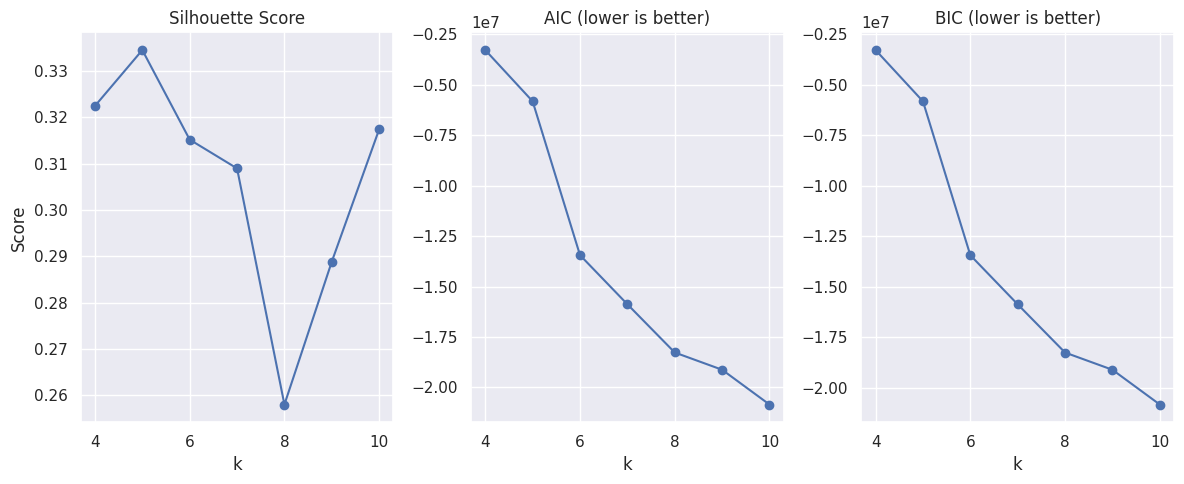

In [ ]:
plt.figure(figsize=(12,5))

# Silhouette
plt.subplot(1,3,1)
plt.plot(ks, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

# AIC
plt.subplot(1,3,2)
plt.plot(ks, aic_scores, marker='o')
plt.title("AIC (lower is better)")
plt.xlabel("k")

# BIC
plt.subplot(1,3,3)
plt.plot(ks, bic_scores, marker='o')
plt.title("BIC (lower is better)")
plt.xlabel("k")

plt.tight_layout()
plt.show()

In [ ]:
gmm = GaussianMixture(n_components=5, random_state=42)

# Fit + predict
clusters = gmm.fit_predict(X)
df['gmm_cluster'] = clusters
df['gmm_cluster'].value_counts()

,count
gmm_cluster,
1,137010
2,8680
4,4175
3,2603
0,2469


GMM with k = 5 gives similar clusters and silhoutee score as kmeans.

In [ ]:
np.sum(df['k_means_cluster'] != df['gmm_cluster'])

np.int64(4)

The assigned clusters are also same as kmeans.(Only 4 disimilarities)

In [ ]:
summary = df.groupby('gmm_cluster').agg({
    'ctc': 'mean',
    'yoe': 'mean',
    'last_ctc_update': 'mean',
    'designation': 'mean',
    'Class': 'mean',
    'Tier': 'mean'
})

summary

,ctc,yoe,last_ctc_update,designation,Class,Tier
gmm_cluster,,,,,,
0,2.211365e+06,7.432564,6.941677,2.053463,2.243418,2.454435
1,2.447722e+06,10.752529,6.472827,2.143844,2.293205,2.421896
2,4.216574e+06,16.925115,6.778802,2.015438,2.101267,1.745968
3,4.543273e+06,9.966577,6.088744,2.187476,2.433730,2.631195
4,1.677686e+06,12.935090,6.837365,2.022275,2.111856,2.395449


Even the gmm cluster summary is very similar to kmeans.

At k = 8, gmm give slightly high silhoutee score, GMM prefers finer segmentation here.

In [ ]:
gmm = GaussianMixture(n_components=8, random_state=42)

# Fit + predict
clusters = gmm.fit_predict(X)
df['gmm_cluster_8'] = clusters
df['gmm_cluster_8'].value_counts()

,count
gmm_cluster_8,
5,54120
1,47104
2,23445
3,9217
7,8680
6,7299
4,2603
0,2469


In [ ]:
summary = df.groupby('gmm_cluster_8').agg({
    'ctc': 'mean',
    'yoe': 'mean',
    'last_ctc_update': 'mean',
    'designation': 'mean',
    'Class': 'mean',
    'Tier': 'mean'
})

summary.sort_values(by='ctc', ascending=False)

,ctc,yoe,last_ctc_update,designation,Class,Tier
gmm_cluster_8,,,,,,
4,4.543273e+06,9.966577,6.088744,2.187476,2.433730,2.631195
7,4.216574e+06,16.925115,6.778802,2.015438,2.101267,1.745968
5,3.084967e+06,10.434276,6.454361,2.228585,2.392369,2.510292
0,2.211365e+06,7.432564,6.941677,2.053463,2.243418,2.454435
1,2.114284e+06,11.317213,6.622155,2.094408,2.243907,2.358377
2,1.940153e+06,10.068074,6.195010,2.100149,2.245511,2.419109
3,1.927792e+06,11.338505,6.387762,2.057611,2.181621,2.397526
6,1.721026e+06,12.175092,6.854364,2.014249,2.066447,2.200986


`KMeans(k=5) and GMM(k=5) both gave: broad segments (macro clusters)`

`GMM (k=8) giving: splitting those into finer sub-groups (micro clusters)`

Seems like GMM(k=8) just uncovered hierarchical structure in the data.

# Clustering Insights (KMeans vs GMM)

Multiple clustering approaches were applied:

- **KMeans (k=5)** and **GMM (k=5)**→ Broad segmentation (macro clusters)
- **Gaussian Mixture Model (k=8)** → Fine-grained segmentation (micro clusters)

This combination reveals a **hierarchical structure** in learner data:
> Broad groups exist, but each contains meaningful sub-groups.

---

# GMM (k=8) Cluster Interpretation

## Top Tier Segments

### Cluster 4 — Elite High Performers
- **CTC:** ~45 LPA (highest)  
- **YOE:** ~10  
- **Tier:** ~2.63 (highest)  

**Insight:**  
Top earners working in premium companies.  
> Same as KMeans elite cluster

---

### Cluster 7 — Veteran Underpaid Professionals
- **CTC:** ~42 LPA  
- **YOE:** ~17 (highest)  
- **Tier:** ~1.74 (lowest)  

**Insight:**  
Highly experienced professionals stuck in low-paying companies.  
> Strong candidates for job switch

---

## Mid-High Segment

### Cluster 5 — Well-Paid Mid Seniors
- **CTC:** ~30 LPA  
- **YOE:** ~10  
- **Tier:** ~2.51  

**Insight:**  
Professionals transitioning toward elite category  
> Strong growth trajectory

---

## Mid-Level Segments

### Cluster 0 — Mid-Level Stable
- **CTC:** ~22 LPA  
- **YOE:** ~7.4  

---

### Cluster 1 — Experienced but Slightly Underpaid
- **CTC:** ~21 LPA  
- **YOE:** ~11  

---

### Cluster 2 — Mid-Level Average
- **CTC:** ~19 LPA  
- **YOE:** ~10  

---

**Insight:**  
These clusters have **similar salaries but different experience levels**

GMM reveals:
> Salary alone does not define career stage

---

## Bottom Segment

### Cluster 3 — Experienced with Underpaid
- **CTC:** ~19 LPA  
- **YOE:** ~11.3

### Cluster 6 — Experienced Low Earners
- **CTC:** ~17 LPA (lowest)  
- **YOE:** ~12  

**Insight:**  
Highly experienced but severely underpaid professionals  
→ Worst-performing segment

---

# Insights

## 1. Hidden Layers Within Salary Bands
- KMeans(k=5) and GMM(k=5) grouped similar salaries together  
- GMM(k=8) split them based on experience  

---

## 2. Underpaid Segment is Not Uniform
Different types of underpaid professionals:
- Early stagnation  
- Mid-career stagnation  
- Late-career stagnation  

---

## 3. Experience vs Salary Mismatch
- Same salary != same experience

In [ ]:
company_cluster_dist = df.groupby('company_hash')['gmm_cluster_8'] \
    .value_counts(normalize=True) \
    .unstack(fill_value=0)

company_cluster_dist.sample(10)

gmm_cluster_8,0,1,2,3,4,5,6,7
company_hash,,,,,,,,
meswz okggsw toidj,0.0,0.0,1.0,0.00,0.0,0.00,0.0,0.0
lkjfiuf li jvw nwc,0.0,0.0,0.0,1.00,0.0,0.00,0.0,0.0
pignsuz ozfidolzf jwz nwc,0.0,0.0,0.0,0.00,0.0,0.00,0.0,1.0
ha imu fwkowdj,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0
suwztokwsiu msqkocf,0.0,0.0,0.0,0.25,0.0,0.25,0.5,0.0
gspkr,0.0,0.0,1.0,0.00,0.0,0.00,0.0,0.0
lzf subiohkwsiu wzleuinitszf jvw nwc,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0
lstusws wzleuinitszf nshswzc,0.0,0.0,0.0,0.00,0.0,1.00,0.0,0.0
ti cstsw,0.0,0.0,0.0,0.00,0.0,1.00,0.0,0.0


In [ ]:

persona_map = {
    0: "Mid-Level Stable",
    1: "Experienced but Slightly Underpaid",
    2: "Mid-Level Average",
    3: "Experienced with Underpaid",
    4: "Elite High Performers",
    5: "Well-Paid Mid Seniors",
    6: "Experienced Low Earners",
    7: "Veteran Underpaid"
}

df['gmm_8_persona'] = df['gmm_cluster_8'].map(persona_map)
df['gmm_8_persona'].value_counts()

,count
gmm_8_persona,
Well-Paid Mid Seniors,54120
Experienced but Slightly Underpaid,47104
Mid-Level Average,23445
Experienced with Underpaid,9217
Veteran Underpaid,8680
Experienced Low Earners,7299
Elite High Performers,2603
Mid-Level Stable,2469


In [ ]:
persona_summary = df.groupby('gmm_8_persona')[[
    'ctc', 'yoe'
]].mean()

persona_summary.sort_values(by='ctc', ascending=False)

,ctc,yoe
gmm_8_persona,,
Elite High Performers,4.543273e+06,9.966577
Veteran Underpaid,4.216574e+06,16.925115
Well-Paid Mid Seniors,3.084967e+06,10.434276
Mid-Level Stable,2.211365e+06,7.432564
Experienced but Slightly Underpaid,2.114284e+06,11.317213
Mid-Level Average,1.940153e+06,10.068074
Experienced with Underpaid,1.927792e+06,11.338505
Experienced Low Earners,1.721026e+06,12.175092


In [ ]:
company_persona = df.groupby('company_hash')['gmm_8_persona'] \
    .value_counts(normalize=True) \
    .unstack(fill_value=0)

company_persona.sample(10)

gmm_8_persona,Elite High Performers,Experienced Low Earners,Experienced but Slightly Underpaid,Experienced with Underpaid,Mid-Level Average,Mid-Level Stable,Veteran Underpaid,Well-Paid Mid Seniors
company_hash,,,,,,,,
ckufrz gkursw,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000
cznn suwzoukwsiukn fzovslzf gkemku lagzowzr liufdnwsut,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.000000
oiductnkff e2i jvw nwc,0.0,0.0,0.5,0.500000,0.0,0.0,0.0,0.000000
esfwitzuzwslf sucsk jvw nwc,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000
fkhfdut znzlwoiuslf sucsk jvw nwc,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.000000
suldgawz,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.000000
iufswz znzlwoi fzovslzf,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.000000
fwkohkor fibwmkoz,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000
jsur lkjswkn,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.666667


#Visualization After clustering

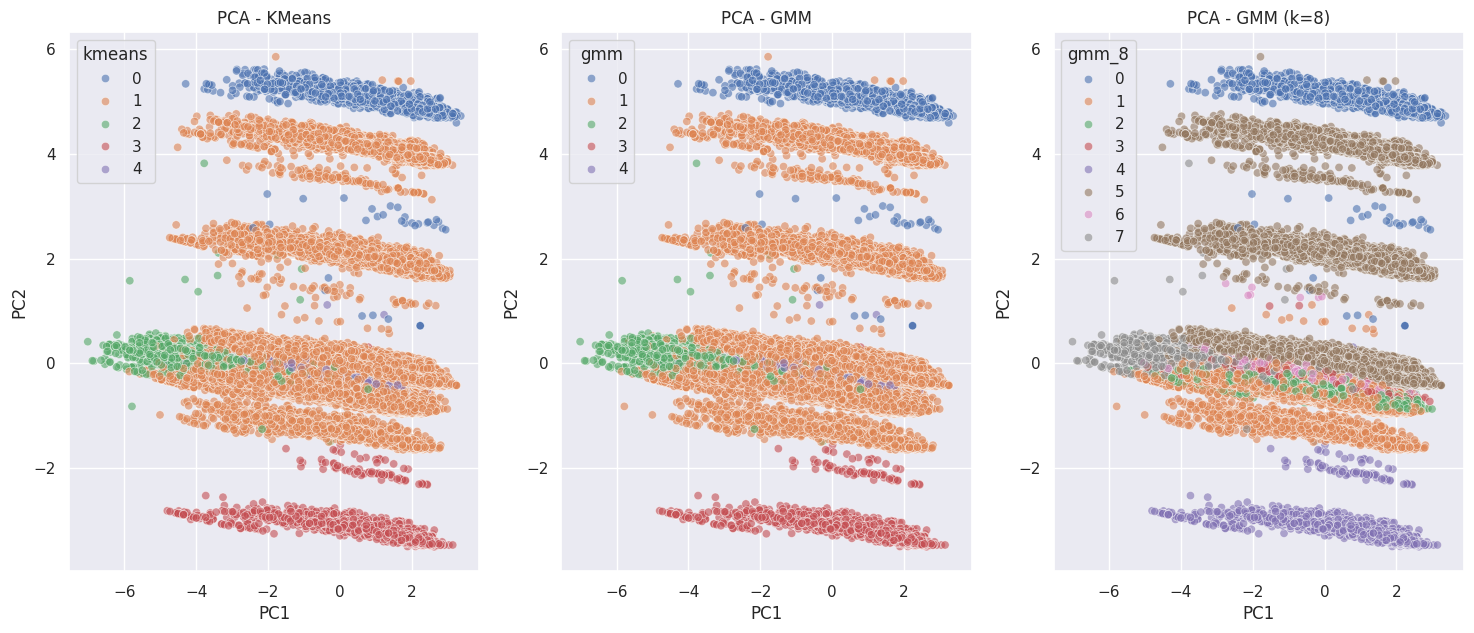

In [ ]:
kmeans_labels = df['k_means_cluster']
gmm_labels = df['gmm_cluster']
gmm_8_labels = df['gmm_cluster_8']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['kmeans'] = kmeans_labels.values
pca_df['gmm'] = gmm_labels.values
pca_df['gmm_8'] = gmm_8_labels.values

fig, ax = plt.subplots(1,3, figsize=(18,7))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='kmeans', ax=ax[0], palette='deep', alpha=0.6)
ax[0].set_title("PCA - KMeans")

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='gmm', ax=ax[1], palette='deep', alpha=0.6)
ax[1].set_title("PCA - GMM")

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='gmm_8', ax=ax[2], palette='deep', alpha=0.6)
ax[2].set_title("PCA - GMM (k=8)")

plt.show()

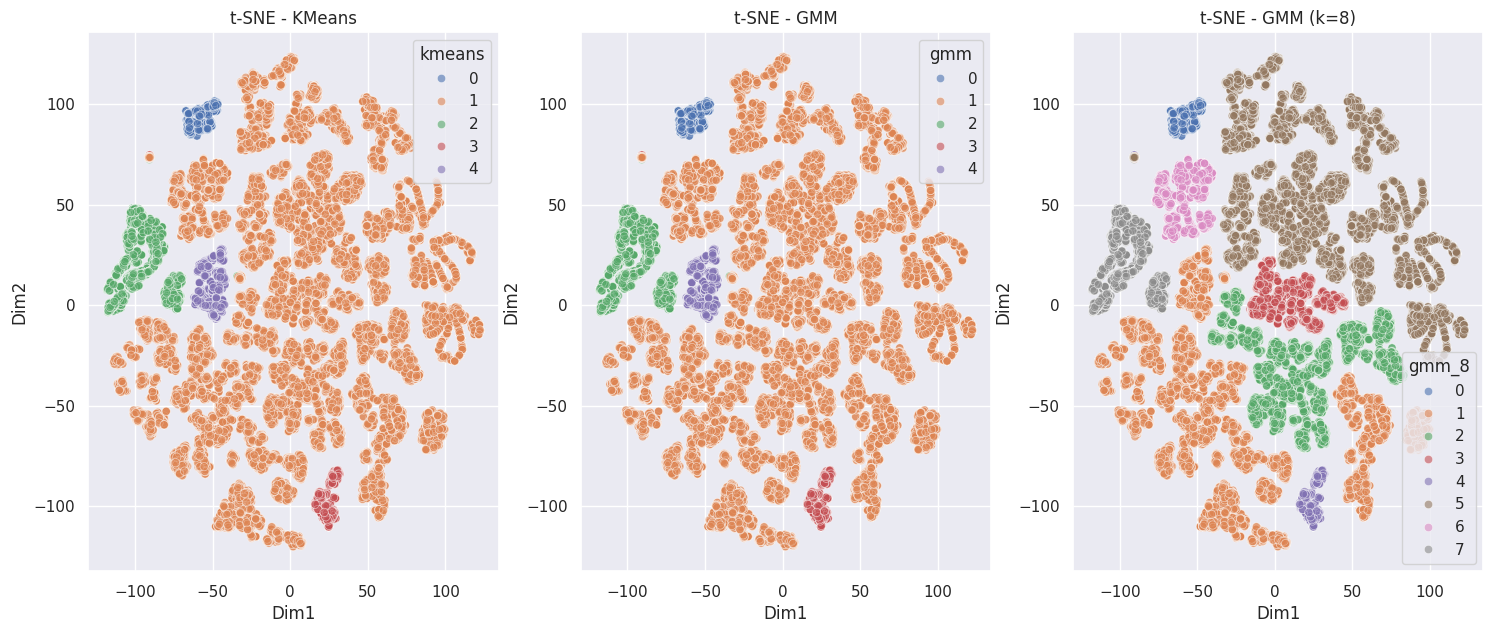

In [ ]:
# sample (t-SNE is slow)
idx = np.random.choice(len(X), 50000, replace=False)
X_sample = X[idx]

tsne = TSNE(n_components=2, perplexity=70, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame(X_tsne, columns=['Dim1','Dim2'])
tsne_df['kmeans'] = kmeans_labels.iloc[idx].values
tsne_df['gmm'] = gmm_labels.iloc[idx].values
tsne_df['gmm_8'] = gmm_8_labels.iloc[idx].values

fig, ax = plt.subplots(1,3, figsize=(18,7))

sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='kmeans', ax=ax[0], palette='deep', alpha=0.6)
ax[0].set_title("t-SNE - KMeans")

sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='gmm', ax=ax[1], palette='deep', alpha=0.6)
ax[1].set_title("t-SNE - GMM")

sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='gmm_8', ax=ax[2], palette='deep', alpha=0.6)
ax[2].set_title("t-SNE - GMM (k=8)")

plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


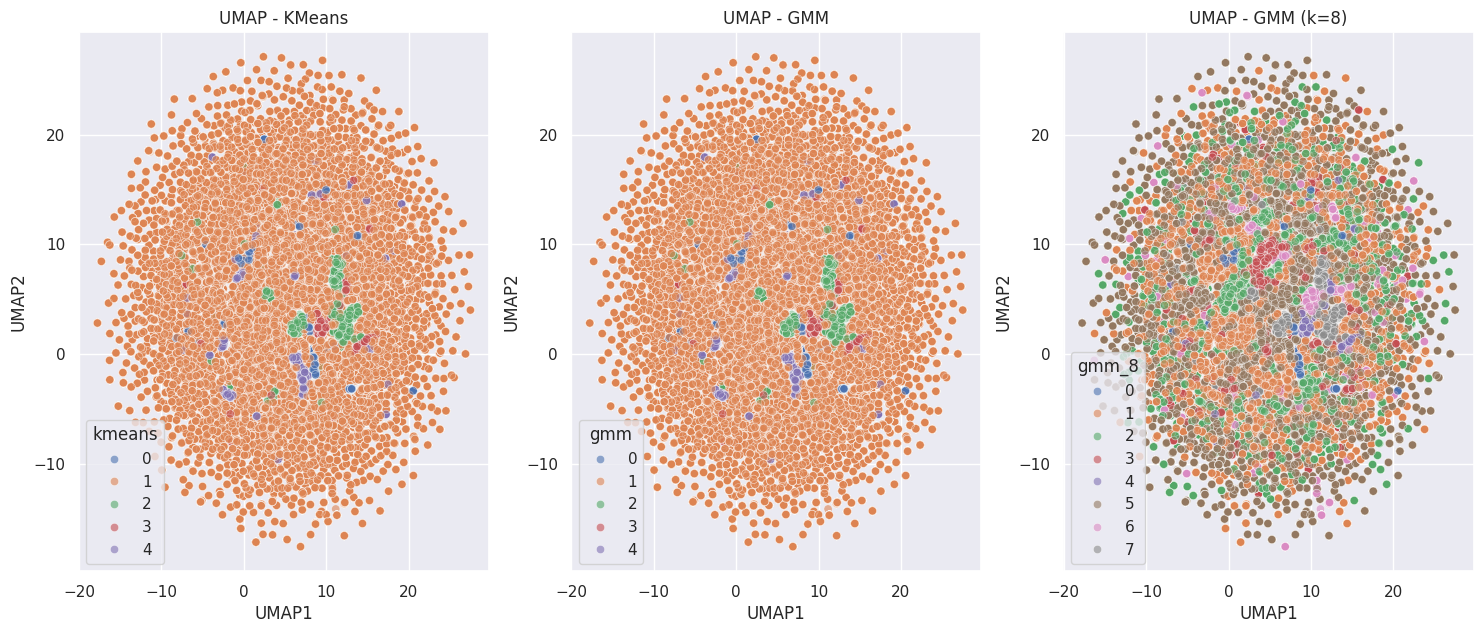

In [ ]:
import umap.umap_ as umap
X_pca_10 = PCA(n_components=10).fit_transform(X)

umap_model = umap.UMAP(n_components=2, init='random', random_state=42)
X_umap = umap_model.fit_transform(X_pca_10)

umap_df = pd.DataFrame(X_umap, columns=['UMAP1','UMAP2'])
umap_df['kmeans'] = kmeans_labels.values
umap_df['gmm'] = gmm_labels.values
umap_df['gmm_8'] = gmm_8_labels.values

fig, ax = plt.subplots(1,3, figsize=(18,7))

sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='kmeans', ax=ax[0], palette='deep', alpha=0.6)
ax[0].set_title("UMAP - KMeans")

sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='gmm', ax=ax[1], palette='deep', alpha=0.6)
ax[1].set_title("UMAP - GMM")

sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='gmm_8', ax=ax[2], palette='deep', alpha=0.6)
ax[2].set_title("UMAP - GMM (k=8)")

plt.show()

#Hirarchical(Agglomeritive)

In [ ]:
sample_idx = np.random.choice(len(X), 25000, replace=False)
X_sample = X[sample_idx]

In [ ]:
from scipy.cluster.hierarchy import linkage

Z = linkage(X_sample, method='ward')  # best for euclidean

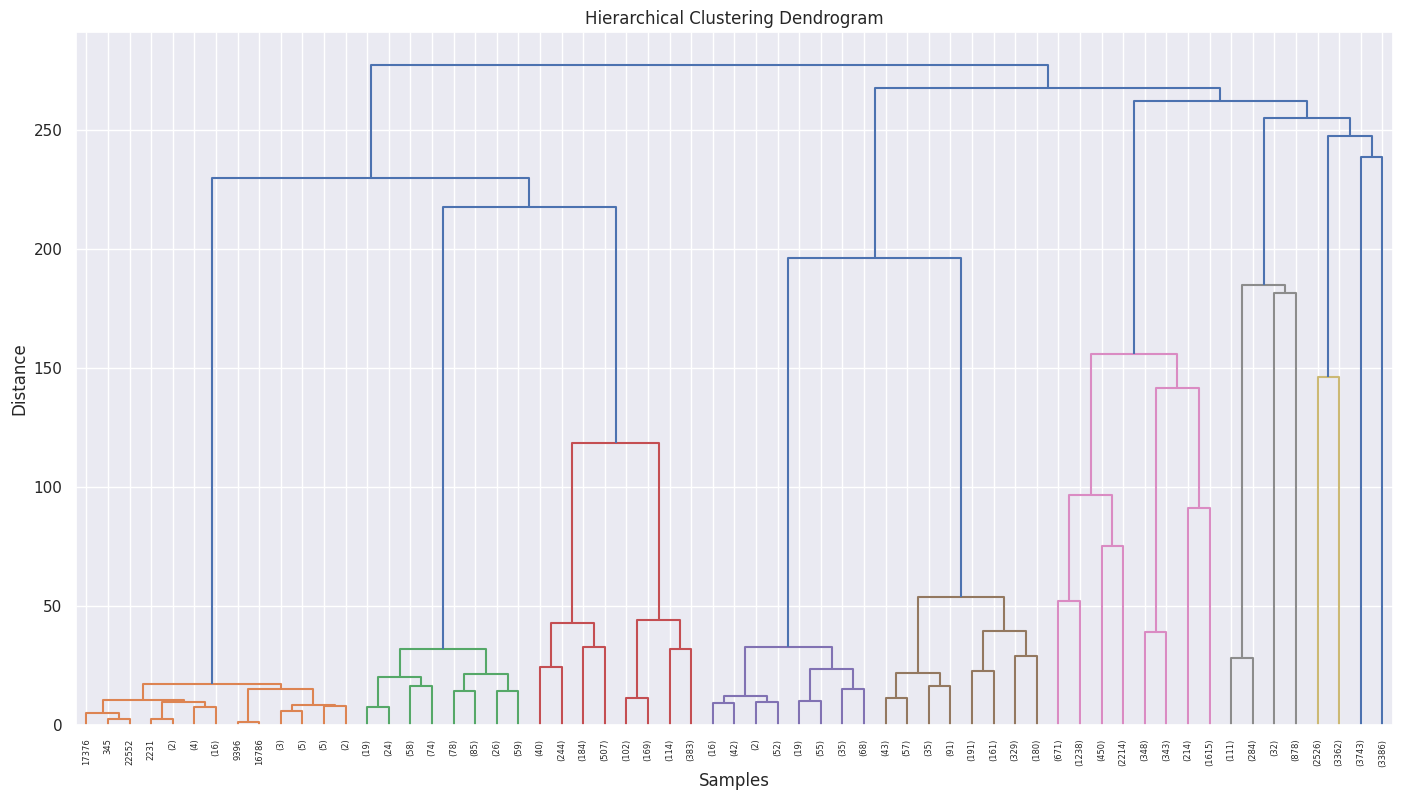

In [ ]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(17,9))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=8,        # choose k
    linkage='ward'       # best for euclidean
)

labels_hc = hc.fit_predict(X_sample)

In [ ]:
df_sample = df.iloc[sample_idx].copy()
df_sample['hc_cluster'] = labels_hc

In [ ]:
df_sample.groupby('hc_cluster')[['ctc', 'yoe', 'last_ctc_update', 'Class', 'Tier']].mean()

,ctc,yoe,last_ctc_update,Class,Tier
hc_cluster,,,,,
0,1.115451e+06,10.465369,6.420552,2.325487,2.564056
1,1.500548e+06,12.509740,6.861472,2.089827,2.294913
2,3.181878e+06,16.928779,6.750000,2.093750,1.742006
3,4.568951e+06,10.210771,6.487382,2.410828,2.508107
4,2.597344e+06,10.945594,6.444444,2.218391,2.353257
5,1.652525e+06,11.092221,6.652344,2.304008,2.389776
6,1.349626e+06,10.091371,6.200908,2.261288,2.420785
7,1.177473e+06,11.426528,6.369311,2.148244,2.401170


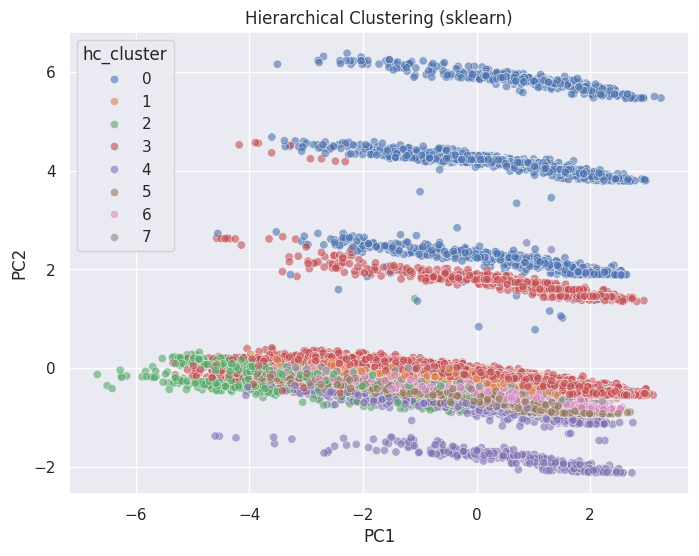

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plot_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
plot_df['hc_cluster'] = labels_hc

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='hc_cluster', palette='deep', alpha=0.6)
plt.title("Hierarchical Clustering (sklearn)")
plt.show()

# Hierarchical Clustering Insights

Agglomerative (Hierarchical) Clustering was applied on a **sampled subset** of the dataset due to scalability constraints. The goal was to validate patterns observed from KMeans and GMM.

---

## Clusters

### Elite High Performers
- **CTC:** ~45 LPA  
- **YOE:** ~10  
- **Tier:** High  

**Insight:**  
Consistently identified across:
- KMeans  
- GMM  
- Hierarchical  

Represents **top-tier talent in premium companies**

---

###Veteran Underpaid Professionals
- **CTC:** ~30-42 LPA  
- **YOE:** ~17 (highest)  
- **Tier:** Low  

**Insight:**  
Also consistently identified across all models.

Represents:
> Highly experienced professionals in low-paying companies  
> Strong candidates for job switch

---

## Mid / Low Salary Segments (Over-Segmented)

Multiple clusters (0,1,5,6,7) show:

Cluster range : Low-Mid

CTC : 11-16 LPA

YOE : ~10-12

**Observation:**
- Similar salary ranges  
- Similar experience levels  
- No strong distinguishing features  

---

#Insight

- Hierarchical clustering **over-segmented** the mid/low salary group
- Successfully identified major segments
- Failed to produce meaningful fine-grained clusters for mid-level data maybe because of i am running it on a subset of data

#DBSCAN

In [ ]:
X_pca = PCA(n_components=10).fit_transform(X)

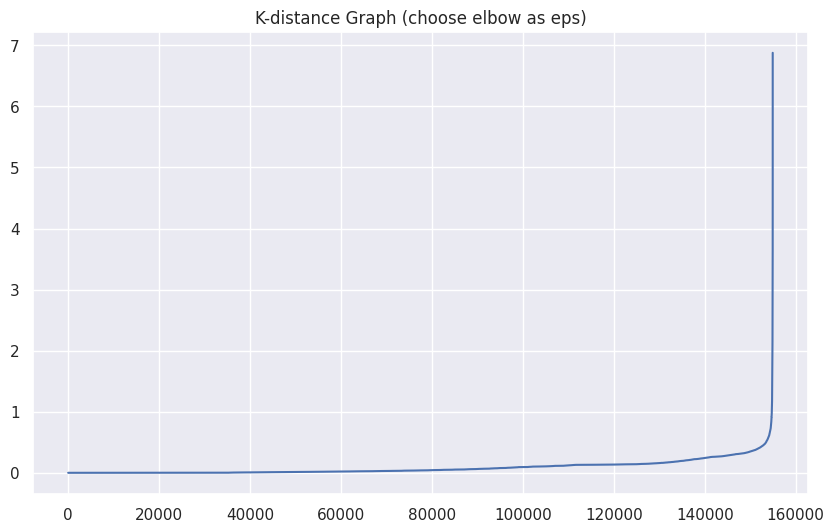

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-distance Graph (choose elbow as eps)")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.6, min_samples=10)  # adjust eps after plot
labels = db.fit_predict(X_pca)

df['dbscan_cluster'] = labels

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique, counts))

{np.int64(-1): np.int64(775),
 np.int64(0): np.int64(37255),
 np.int64(1): np.int64(23417),
 np.int64(2): np.int64(38557),
 np.int64(3): np.int64(5277),
 np.int64(4): np.int64(9190),
 np.int64(5): np.int64(4346),
 np.int64(6): np.int64(4806),
 np.int64(7): np.int64(6768),
 np.int64(8): np.int64(4141),
 np.int64(9): np.int64(2468),
 np.int64(10): np.int64(7260),
 np.int64(11): np.int64(2414),
 np.int64(12): np.int64(1778),
 np.int64(13): np.int64(6080),
 np.int64(14): np.int64(247),
 np.int64(15): np.int64(7),
 np.int64(16): np.int64(38),
 np.int64(17): np.int64(84),
 np.int64(18): np.int64(13),
 np.int64(19): np.int64(16)}

In [ ]:
df.groupby('dbscan_cluster')[['ctc','yoe']].mean().sort_values(by='ctc', ascending=False)

,ctc,yoe
dbscan_cluster,,
-1,2.776113e+07,18.672258
9,4.547304e+06,9.786467
7,3.746981e+06,17.367169
2,3.424484e+06,9.978888
6,3.205175e+06,9.936538
12,3.019705e+06,15.033746
0,2.083811e+06,11.109918
3,1.995626e+06,11.241046
1,1.916681e+06,10.045522


Cluster -1 (noise)
CTC: ~2.7 Cr (!!)
YOE: ~18.6

These are: extreme outliers / ultra high earners

DBSCAN correctly isolated extremes

mid-level professionals split into many tiny clusters

so no density based group exists

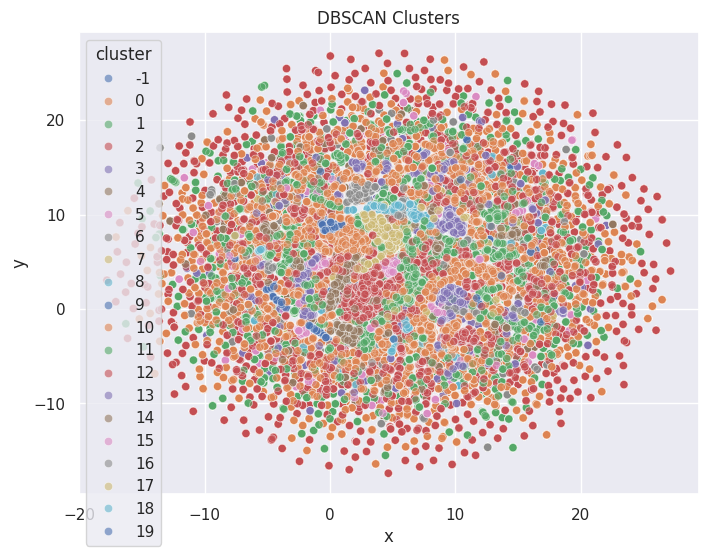

In [ ]:
X_umap = umap.UMAP(n_components=2, init='random').fit_transform(X_pca)

plot_df = pd.DataFrame(X_umap, columns=['x','y'])
plot_df['cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', palette='deep', alpha=0.6)
plt.title("DBSCAN Clusters")
plt.show()

---

# Actionable Insights & Recommendations

This analysis focuses on clustering learners based on job profiles, company, compensation (CTC), and experience to identify meaningful segments and derive actionable business insights for Scaler.

---

# Learner-Level Insights

## 1. High-Value Talent Segment (Elite Earners)

### Insight
- High CTC (~40-45 LPA)  
- Moderate experience (~8-10 years)  
- Strong performance across companies  

Represents **top-performing professionals in high-paying environments**

### Recommendation
- Build partnerships with companies employing this segment  
- Use them as:
  - mentors  
  - success stories for advertisements

---

## 2. Underpaid Experienced Professionals

### Insight
- High experience (~15-17 years)  
- Lower relative compensation (low Tier)  
- Career stagnation or poor company compensation

### Recommendation
- Target with **upskilling and transition programs**  
- Promote:
  - "Switch to high-paying roles"
- Build **career acceleration tracks**

---

##3. Mid-Level Professionals (Largest Segment)

### Insight
- Majority of dataset  
- 8-12 years experience  
- Moderate salaries (10-25 LPA)  
- No clear cluster boundaries i.e. seems continous data(career progression not discrete clusters)

### Recommendation
- Provide **personalized learning paths**
- Offer specialization tracks:
  - Backend
  - Data Science  
  - DevOps
  - Data Engineering
  - Cyber Security

---

## 4. Entry-Level / Low Earners

### Insight
- Low CTC ( less than 10-12 LPA)  
- Early career stage  
- Often interns or junior roles  

### Recommendation
- Offer:
  - beginner-focused programs
  - upskilling program
  - placement-driven courses  
- Focus on:
  - resume building  
  - interview preparation with mocks
  - mentor seession
  - career track building

---


# Company-Level Insights

## High-Paying Companies

### Insight
- High average CTC  
- Higher proportion of Tier 1 (top earners)  

### Recommendation
- Prioritize partnerships  
- Promote as: "Top companies to work for"

---

## Low-Paying Companies

### Insight
- Low average CTC  
- Higher presence of Tier 3 (low earners)  

### Recommendation
- Position as:
  - "career switch opportunities" for these company employees

---

# Role-Based Insights

## High-Paying Roles
- Backend Engineer  
- Data Scientist  
- Fullstack Engineer  

### Recommendation
- Focus curriculum on:
  - backend systems  
  - machine learning  
- Highlight these roles in marketing  

---

## Lower-Paying Roles
- Support Engineer  
- Testing roles  
- Non-technical roles  

### Recommendation
- Create **transition pathways** to:
  - backend  
  - data  
  - devops roles  

---

#Recommendations

## 1. Build Learner Personas
- Elite Performer  
- Underpaid Veteran  
- Growth-Stage Professional  
- Entry-Level  

Use for:
- targeted marketing  
- course recommendations  


One line Actionable insight : Career growth is continuous rather than clustered, so personalized progression strategies will outperform rigid segmentation.